# Análisis y Preparación de Datos — Reingreso Hospitalario a 30 días
### Proyecto #1 · Planificación y Toma de Decisiones en IA
**Dataset:** Diabetes 130-US Hospitals (1999–2008) · 101 766 encuentros · 71 518 pacientes · 130 hospitales




## Configuración Inicial


In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Paleta categórica validada (orden fijo, apta para daltonismo) y tinta neutra
C1, C2, C3, C4, C5, C6, C7, C8 = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                                  "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
PALETTE = [C1, C2, C3, C4, C5, C6, C7, C8]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "lines.linewidth": 2,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

DATA_DIR = Path(".")
ART_DIR = Path("artifacts")
ART_DIR.mkdir(exist_ok=True)
print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| numpy", np.__version__)

pandas 2.3.3 | scikit-learn 1.7.2 | numpy 2.3.3


## 1.  Auditoría de calidad de datos

En el dataset se encontro lo siguiente:
- Los faltantes vienen codificados como `"?"` → `na_values="?"`.
- En `max_glu_serum` y `A1Cresult` el valor `"None"` **no es un faltante**: significa *prueba no realizada*, lo cual es informativo. Por eso se desactiva `keep_default_na` (pandas convertiría `"None"` en NaN).

In [2]:
raw = pd.read_csv(DATA_DIR / "diabetic_data.csv", na_values="?", keep_default_na=False, low_memory=False)
print(f"Filas: {raw.shape[0]:,} | Columnas: {raw.shape[1]}")
print(f"Encuentros únicos: {raw.encounter_id.nunique():,} | Pacientes únicos: {raw.patient_nbr.nunique():,}")
raw.head()

Filas: 101,766 | Columnas: 50
Encuentros únicos: 101,766 | Pacientes únicos: 71,518


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
def load_id_mappings(path):
    # El archivo contiene 3 tablas apiladas separadas por líneas vacías
    maps, current = {}, None
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        if not line.strip(", "):
            current = None
            continue
        key, _, desc = line.partition(",")
        if current is None:
            current = key
            maps[current] = {}
        else:
            maps[current][int(key)] = desc.strip().strip('"').strip()
    return maps

ID_MAPS = load_id_mappings(DATA_DIR / "IDS_mapping.csv")
for k, v in ID_MAPS.items():
    print(f"{k}: {len(v)} códigos")

admission_type_id: 8 códigos
discharge_disposition_id: 30 códigos
admission_source_id: 25 códigos


In [4]:
MED_COLS = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", "acetohexamide",
            "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose", "miglitol",
            "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin",
            "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone"]
NUM_RAW = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
           "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]

def quality_report(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unicos": df.nunique(),
        "%_faltante": df.isna().mean() * 100,
        "valor_mas_frecuente": df.mode(dropna=False).iloc[0],
        "%_mas_frecuente": [df[c].value_counts(normalize=True, dropna=False).iloc[0] * 100 for c in df],
    }).sort_values(["%_faltante", "%_mas_frecuente"], ascending=False)

qrep = quality_report(raw)
qrep.head(20)

,dtype,n_unicos,%_faltante,valor_mas_frecuente,%_mas_frecuente
weight,object,9,96.8585,NaN,96.8585
medical_specialty,object,72,49.0822,NaN,49.0822
payer_code,object,17,39.5574,NaN,39.5574
race,object,5,2.2336,Caucasian,74.7784
diag_3,object,789,1.3983,250,11.3545
diag_2,object,748,0.3518,276,6.6348
diag_1,object,716,0.0206,428,6.7429
examide,object,1,0.0000,No,100.0000
citoglipton,object,1,0.0000,No,100.0000
acetohexamide,object,2,0.0000,No,99.9990


In [5]:
# Faltantes "ocultos": categorías que semánticamente significan desconocido
hidden_na = {
    "admission_type_id": [5, 6, 8],
    "discharge_disposition_id": [18, 25, 26],
    "admission_source_id": [9, 15, 17, 20, 21],
}
EXPIRED_HOSPICE = [11, 13, 14, 19, 20, 21]  # fallecido u hospicio: no pueden reingresar

checks = {
    "encounter_id duplicados": raw.encounter_id.duplicated().sum(),
    "Filas completamente duplicadas": raw.drop(columns=["encounter_id"]).duplicated().sum(),
    "gender = Unknown/Invalid": (raw.gender == "Unknown/Invalid").sum(),
    "Alta por fallecimiento/hospicio": raw.discharge_disposition_id.isin(EXPIRED_HOSPICE).sum(),
    "Columnas constantes": ", ".join(c for c in raw if raw[c].nunique(dropna=False) == 1),
    "Medicamentos con >99.9% 'No'": ", ".join(c for c in MED_COLS if (raw[c] == "No").mean() > 0.999),
}
for col, codes in hidden_na.items():
    checks[f"{col} desconocido (faltante oculto)"] = raw[col].isin(codes).sum()
checks["A1Cresult = None (no medido)"] = (raw.A1Cresult == "None").sum()
checks["max_glu_serum = None (no medido)"] = (raw.max_glu_serum == "None").sum()
pd.Series(checks, name="valor").to_frame()

,valor
encounter_id duplicados,0
Filas completamente duplicadas,0
gender = Unknown/Invalid,3
Alta por fallecimiento/hospicio,2423
Columnas constantes,"examide, citoglipton"
Medicamentos con >99.9% 'No',"chlorpropamide, acetohexamide, tolbutamide, mi..."
admission_type_id desconocido (faltante oculto),10396
discharge_disposition_id desconocido (faltante oculto),4680
admission_source_id desconocido (faltante oculto),7067
A1Cresult = None (no medido),84748


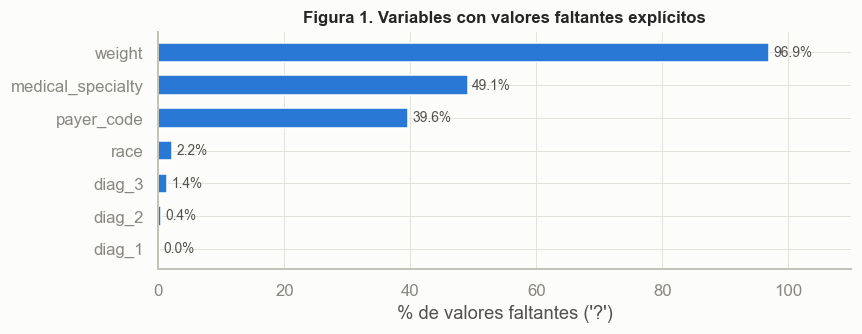

In [6]:
miss = (raw.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(miss.index[::-1], miss.values[::-1], color=C1, height=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=3, color=INK2, fontsize=9)
ax.set_xlabel("% de valores faltantes ('?')"); ax.set_xlim(0, 110)
ax.set_title("Figura 1. Variables con valores faltantes explícitos")
plt.tight_layout(); plt.show()

**Hallazgos importantes:**
- `weight` tiene ~97 % faltante → se **elimina** (no recuperable).
- `medical_specialty` (~49 %) y `payer_code` (~40 %) tienen faltantes altos pero **no aleatorios** (ver Sección 4: cambian con el tiempo) → se tratan como categoría explícita `Missing`.
- `examide` y `citoglipton` son constantes → sin información, se eliminan.
- Existen faltantes ocultos en IDs de admisión/alta (`NULL`, `Not Mapped`, `Not Available`) → se agrupan como `Unknown`.
- Encuentros con alta por **fallecimiento u hospicio** no pueden reingresar: son anomalías respecto de la etiqueta y se excluyen del modelado.
- 3 registros con sexo inválido → se excluyen.

## 2 Construcción y validación del eje temporal

El dataset cubre 10 años (1999–2008) pero **no incluye fechas**. Para respetar la naturaleza temporal usamos `encounter_id` como **proxy del orden cronológico**: los identificadores de encuentro se asignan de forma creciente en el sistema de origen.


Hemos defeinido que el orden será por `encounter_id` es cronológico, cuando un paciente tiene dos encuentros, el *segundo* debería registrar hospitalizaciones previas en el último año (`number_inpatient ≥ 1`) con mucha más frecuencia que el primero. Si el orden fuese arbitrario, invertirlo no cambiaría esa proporción.

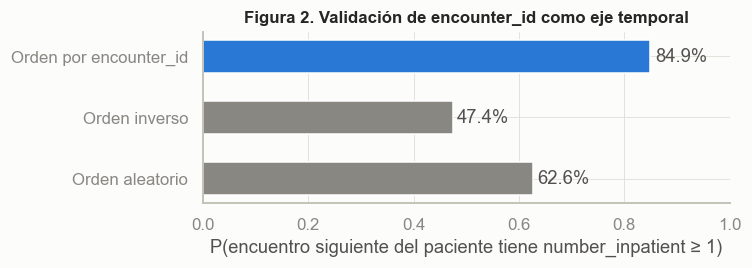

Orden por encounter_id   0.8495
Orden inverso            0.4739
Orden aleatorio          0.6260
dtype: float64

In [7]:
df = raw.sort_values("encounter_id").reset_index(drop=True)
df["t_idx"] = np.arange(len(df))                 # posición cronológica (pseudo-tiempo)
N_PERIODS = 20
df["period"] = df["t_idx"] * N_PERIODS // len(df)  # 20 periodos de igual tamaño (~5 090 encuentros ≈ 6 meses)

def share_next_with_prior_inpatient(d):
    nxt = d.groupby("patient_nbr")["number_inpatient"].shift(-1)
    return (nxt.dropna() >= 1).mean()

val_order = pd.Series({
    "Orden por encounter_id": share_next_with_prior_inpatient(df),
    "Orden inverso": share_next_with_prior_inpatient(df.iloc[::-1]),
    "Orden aleatorio": share_next_with_prior_inpatient(df.sample(frac=1, random_state=SEED)),
})
fig, ax = plt.subplots(figsize=(7, 2.6))
bars = ax.barh(val_order.index[::-1], val_order.values[::-1], color=[MUTED, MUTED, C1], height=0.55)
ax.bar_label(bars, fmt="%.1f%%", labels=[f"{v:.1%}" for v in val_order.values[::-1]], padding=3, color=INK2)
ax.set_xlim(0, 1); ax.set_xlabel("P(encuentro siguiente del paciente tiene number_inpatient ≥ 1)")
ax.set_title("Figura 2. Validación de encounter_id como eje temporal")
plt.tight_layout(); plt.show()
val_order

In [8]:
per = df.groupby("period").agg(n=("encounter_id", "size"),
                               encounter_id_min=("encounter_id", "min"),
                               encounter_id_max=("encounter_id", "max"),
                               pacientes=("patient_nbr", "nunique"))
per.T

period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
n,5089,5088,5088,5089,5088,5088,5089,5088,5088,5088,5089,5088,5088,5089,5088,5088,5089,5088,5088,5088
encounter_id_min,12522,27172062,43368876,58783392,71759598,84964560,98705880,110203032,126329622,141461340,152389680,161173890,170677014,184657854,205988646,230271984,252314172,275116890,311356052,378967640
encounter_id_max,27170358,43367976,58782366,71757270,84960072,98702742,110201076,126324102,141455694,152388294,161161032,170676276,184657590,205985142,230271972,252308694,275114796,311346542,378962852,443867222
pacientes,4335,4444,4466,4392,4448,4622,4601,4552,4572,4538,4529,4518,4563,4426,4452,4471,4495,4609,4692,4684


**Conclusión:** con el orden por `encounter_id`, el siguiente encuentro del mismo paciente registra hospitalizaciones previas en ~85 % de los casos, frente a ~47 % en orden inverso. Esto nos deja afirmar que el orden es claramente cronológico, por lo que:
- se definen **20 periodos** consecutivos de igual tamaño (cada uno ≈ 6 meses si los encuentros se distribuyen uniformemente en 10 años);
- todas las variables rezagadas, las ventanas deslizantes y la partición train/val/test respetan este orden.

*Limitación clara:* el proxy da orden, no distancia real en días; la duración de cada periodo es aproximada.

## 3. EDA general

### 3.1 Variable objetivo

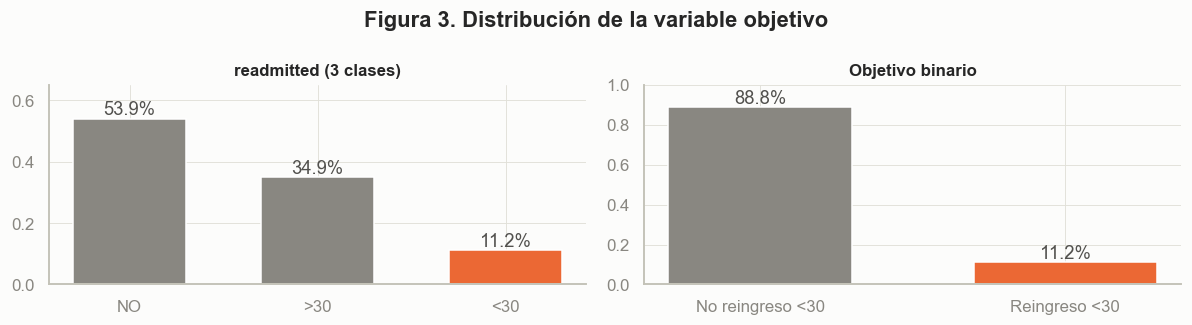

Razón de desbalance: 8.0 negativos por cada positivo


In [9]:
df["target"] = (df.readmitted == "<30").astype(int)
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
vc = df.readmitted.value_counts(normalize=True).reindex(["NO", ">30", "<30"])
b = axes[0].bar(vc.index, vc.values, color=[MUTED, MUTED, C2], width=0.6)
axes[0].bar_label(b, labels=[f"{v:.1%}" for v in vc.values], color=INK2)
axes[0].set_title("readmitted (3 clases)"); axes[0].set_ylim(0, 0.65)
vb = df.target.value_counts(normalize=True).sort_index()
b = axes[1].bar(["No reingreso <30", "Reingreso <30"], vb.values, color=[MUTED, C2], width=0.6)
axes[1].bar_label(b, labels=[f"{v:.1%}" for v in vb.values], color=INK2)
axes[1].set_title("Objetivo binario"); axes[1].set_ylim(0, 1)
fig.suptitle("Figura 3. Distribución de la variable objetivo", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Razón de desbalance: {(1 - df.target.mean()) / df.target.mean():.1f} negativos por cada positivo")

Se define el objetivo como **reingreso en menos de 30 días** (`<30`) vs. el resto, porque es el evento penalizado por HRRP y el accionable con intervenciones de transición. El desbalance (~8:1) implica que *accuracy* no es informativa: se usarán ROC-AUC, PR-AUC, F1, recall y balanced accuracy, y el umbral se ajustará en validación.

### 3.2 Variables numéricas

,count,mean,std,min,25%,50%,75%,max,skew,pct_cero
time_in_hospital,"101,766.0000",4.3960,2.9851,1.0000,2.0000,4.0000,6.0000,14.0000,1.1340,0.0000
num_lab_procedures,"101,766.0000",43.0956,19.6744,1.0000,31.0000,44.0000,57.0000,132.0000,-0.2365,0.0000
num_procedures,"101,766.0000",1.3397,1.7058,0.0000,0.0000,1.0000,2.0000,6.0000,1.3164,0.4584
num_medications,"101,766.0000",16.0218,8.1276,1.0000,10.0000,15.0000,20.0000,81.0000,1.3267,0.0000
number_outpatient,"101,766.0000",0.3694,1.2673,0.0000,0.0000,0.0000,0.0000,42.0000,8.8330,0.8355
number_emergency,"101,766.0000",0.1978,0.9305,0.0000,0.0000,0.0000,0.0000,76.0000,22.8556,0.8881
number_inpatient,"101,766.0000",0.6356,1.2629,0.0000,0.0000,0.0000,1.0000,21.0000,3.6141,0.6646
number_diagnoses,"101,766.0000",7.4226,1.9336,1.0000,6.0000,8.0000,9.0000,16.0000,-0.8767,0.0000


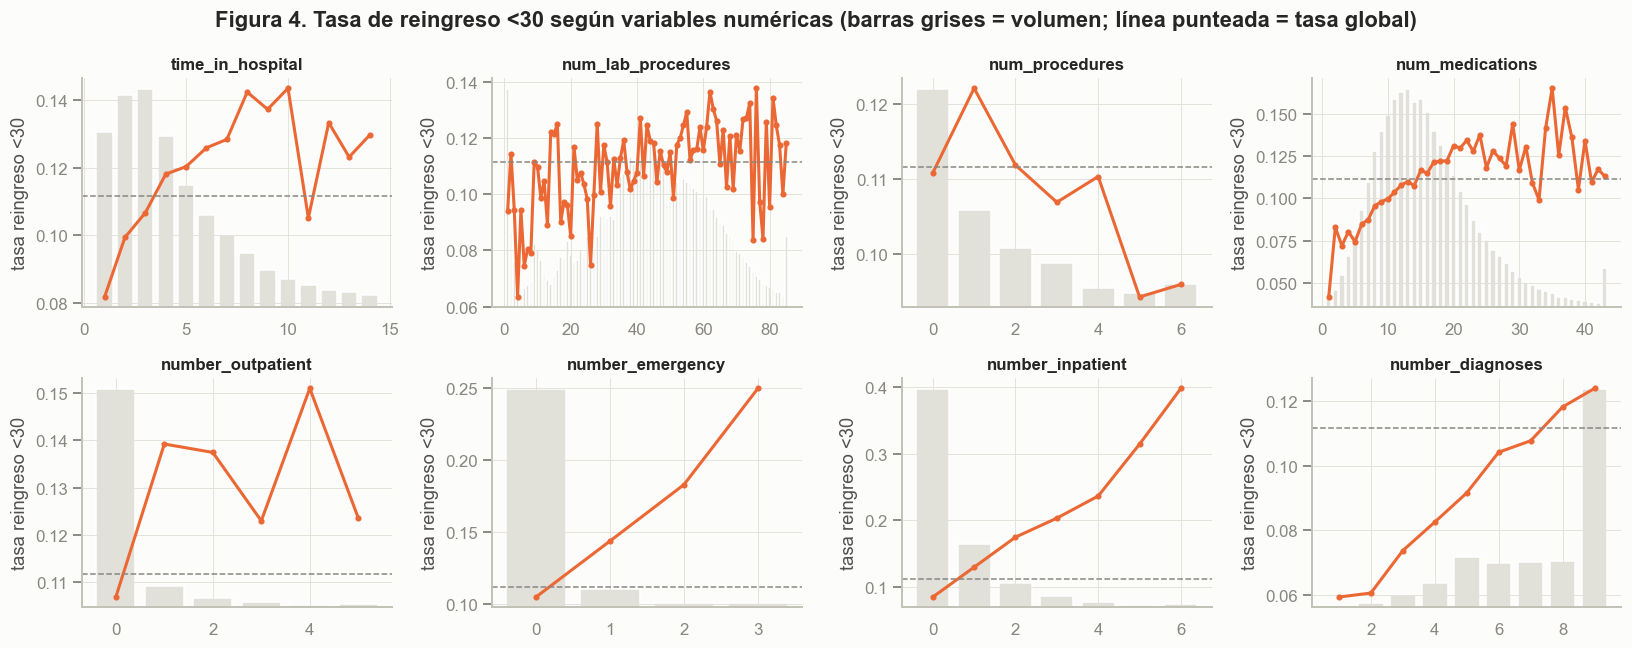

In [10]:
display(df[NUM_RAW].describe().T.assign(skew=df[NUM_RAW].skew(), pct_cero=(df[NUM_RAW] == 0).mean()))

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), NUM_RAW):
    rate = df.groupby(df[col].clip(upper=df[col].quantile(0.99)))["target"].agg(["mean", "size"])
    rate = rate[rate["size"] >= 100]
    ax2 = ax.twinx()
    ax2.bar(rate.index, rate["size"], color=GRID, width=0.8, zorder=0)
    ax2.set_yticks([]); ax2.grid(False)
    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
    ax.plot(rate.index, rate["mean"], color=C2, marker="o", ms=3)
    ax.axhline(df.target.mean(), color=MUTED, ls="--", lw=1)
    ax.set_title(col); ax.set_ylabel("tasa reingreso <30")
fig.suptitle("Figura 4. Tasa de reingreso <30 según variables numéricas (barras grises = volumen; línea punteada = tasa global)",
             fontweight="bold")
plt.tight_layout(); plt.show()

In [11]:
def univariate_signal(d, cols, target="target"):
    rows = []
    for c in cols:
        pos, neg = d.loc[d[target] == 1, c], d.loc[d[target] == 0, c]
        u = stats.mannwhitneyu(pos, neg)
        rows.append({"variable": c, "media_reingreso": pos.mean(), "media_no_reingreso": neg.mean(),
                     "AUC_univariado": roc_auc_score(d[target], d[c]), "p_value_MW": u.pvalue})
    return pd.DataFrame(rows).sort_values("AUC_univariado", ascending=False)

univariate_signal(df, NUM_RAW)

,variable,media_reingreso,media_no_reingreso,AUC_univariado,p_value_MW
6,number_inpatient,1.2240,0.5616,0.6061,0.0000
0,time_in_hospital,4.7682,4.3492,0.5463,0.0000
3,num_medications,16.9031,15.9111,0.5416,0.0000
7,number_diagnoses,7.6928,7.3887,0.5406,0.0000
5,number_emergency,0.3573,0.1778,0.5318,0.0000
4,number_outpatient,0.4369,0.3609,0.5202,0.0000
1,num_lab_procedures,44.2260,42.9536,0.5189,0.0000
2,num_procedures,1.2809,1.3471,0.4947,0.0512


### 3.3 Variables categóricas

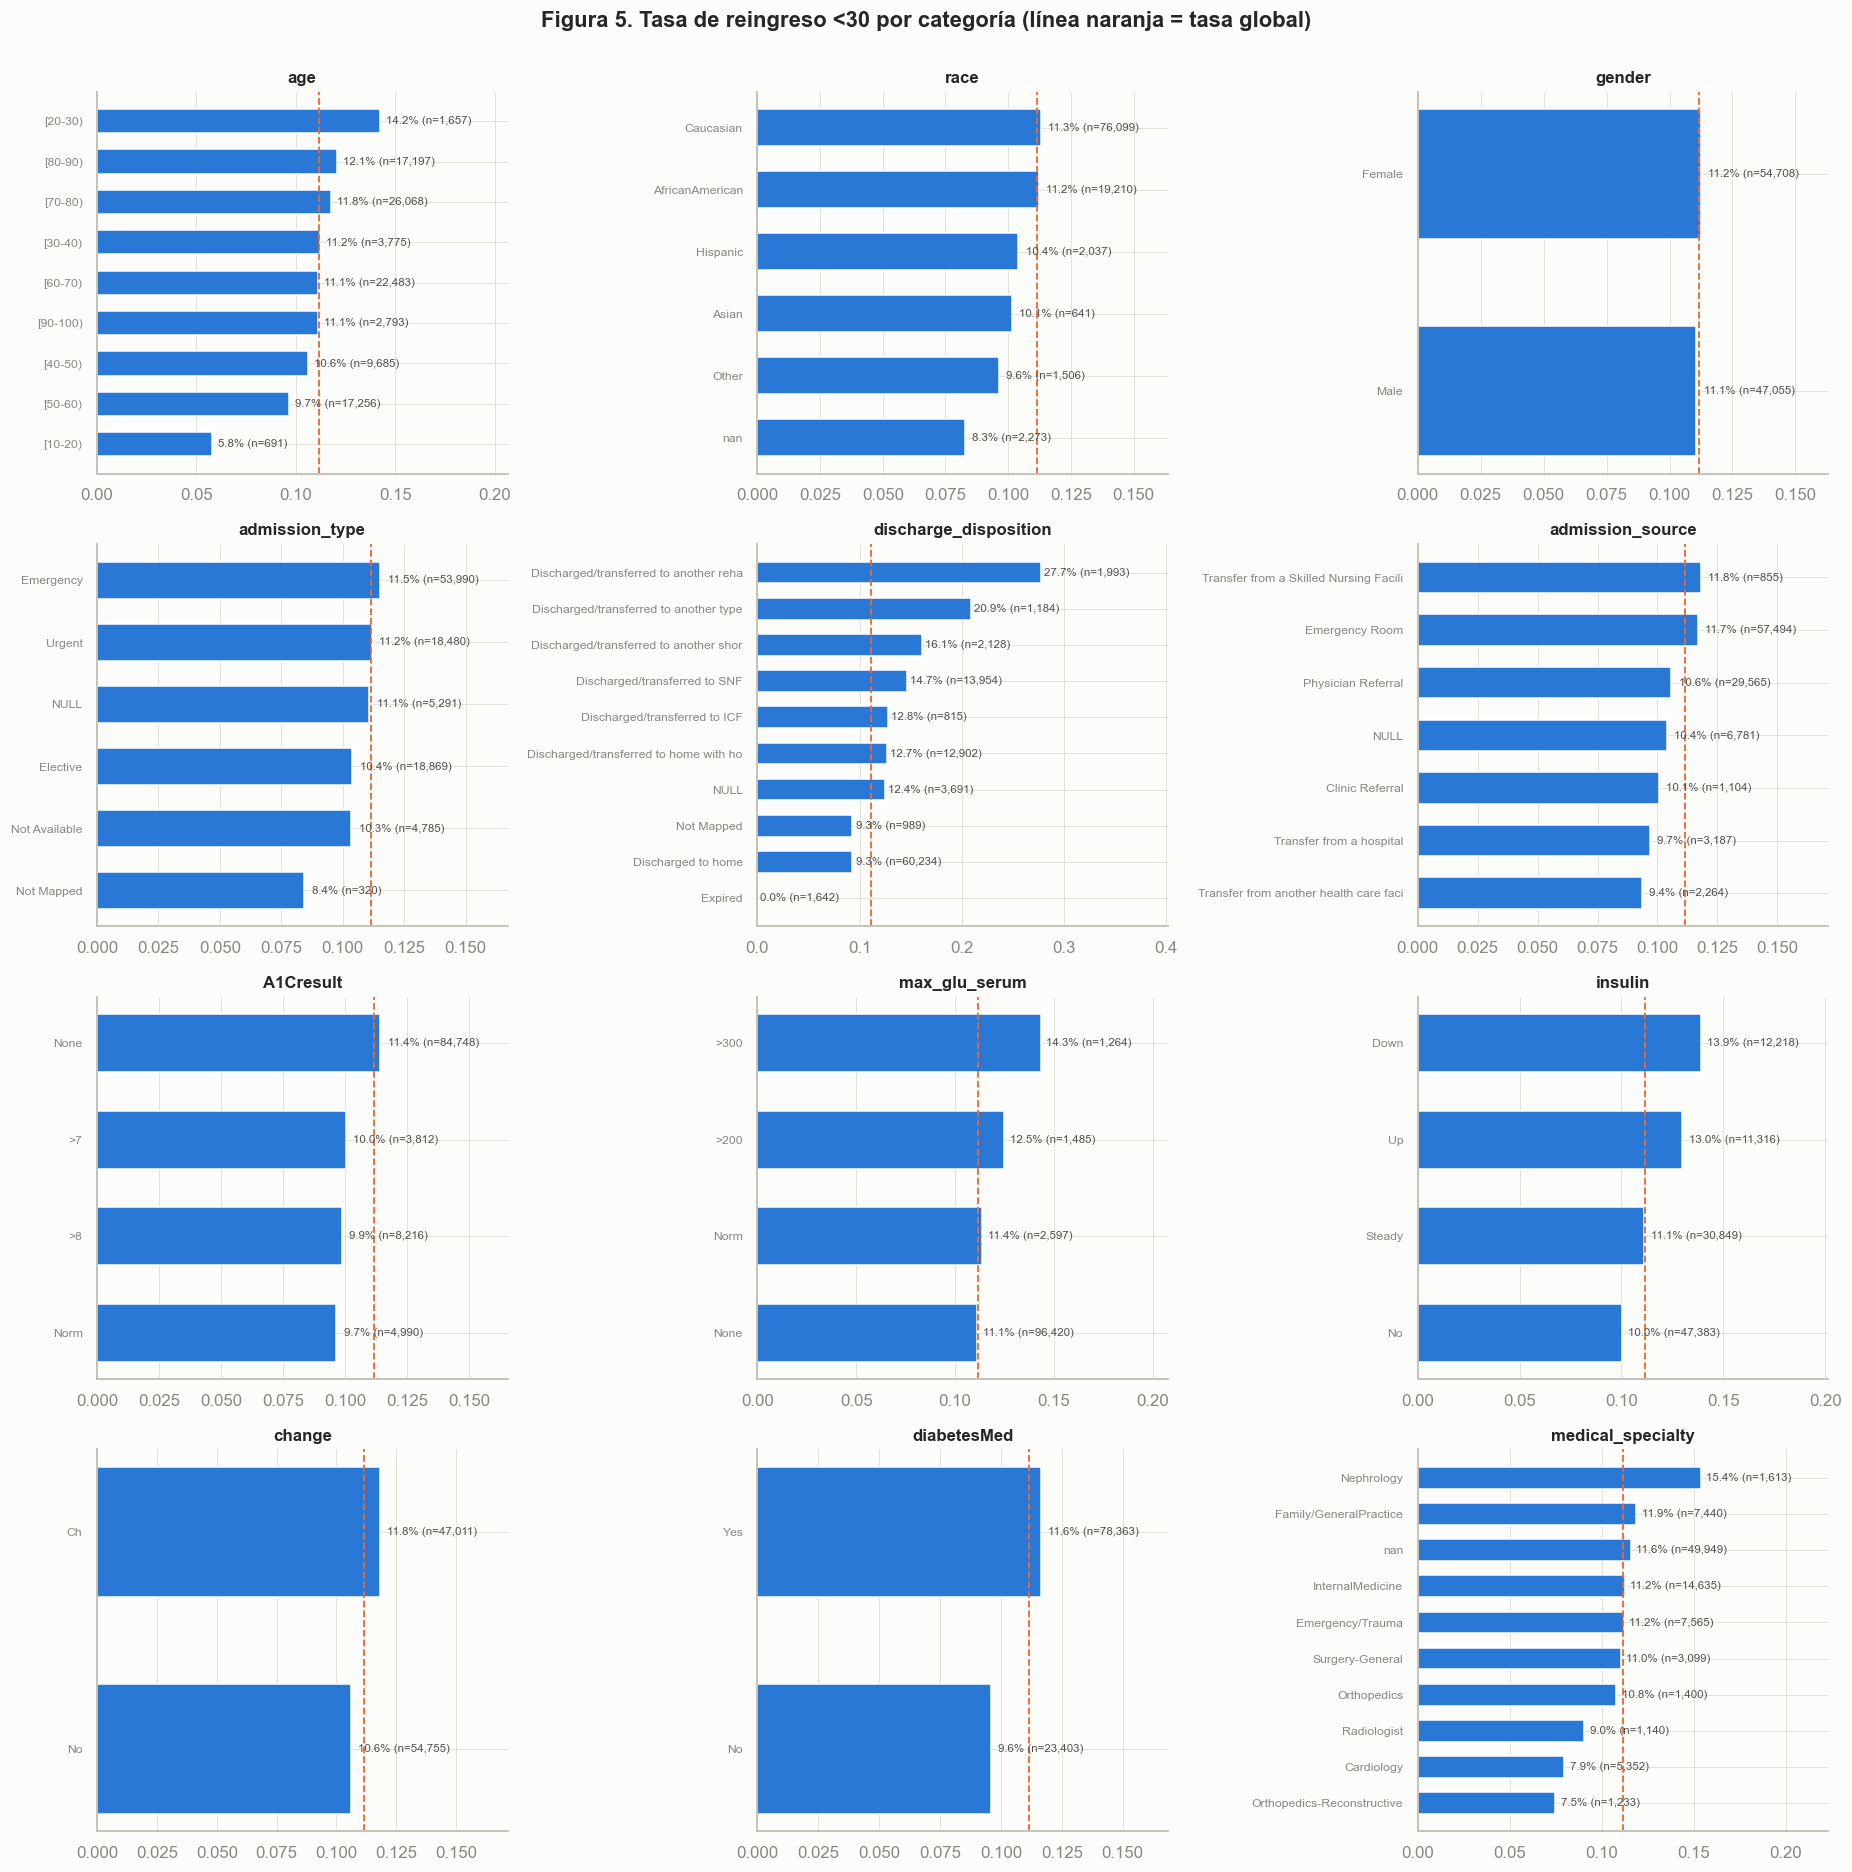

In [12]:
df["admission_type"] = df.admission_type_id.map(ID_MAPS["admission_type_id"])
df["discharge_disposition"] = df.discharge_disposition_id.map(ID_MAPS["discharge_disposition_id"])
df["admission_source"] = df.admission_source_id.map(ID_MAPS["admission_source_id"])

def rate_plot(ax, d, col, top=10, min_n=300):
    g = d.groupby(col, dropna=False)["target"].agg(["mean", "size"])
    g = g[g["size"] >= min_n].sort_values("size", ascending=False).head(top).sort_values("mean")
    labels = [str(i)[:38] for i in g.index]
    ax.barh(labels, g["mean"], color=C1, height=0.6)
    ax.axvline(d.target.mean(), color=C2, ls="--", lw=1.2)
    for y, (m, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(m + 0.003, y, f"{m:.1%} (n={n:,})", va="center", fontsize=7.5, color=INK2)
    ax.set_xlim(0, g["mean"].max() * 1.45); ax.set_title(col); ax.tick_params(axis="y", labelsize=8)

cat_show = ["age", "race", "gender", "admission_type", "discharge_disposition", "admission_source",
            "A1Cresult", "max_glu_serum", "insulin", "change", "diabetesMed", "medical_specialty"]
fig, axes = plt.subplots(4, 3, figsize=(17, 17))
for ax, col in zip(axes.ravel(), cat_show):
    rate_plot(ax, df, col)
fig.suptitle("Figura 5. Tasa de reingreso <30 por categoría (línea naranja = tasa global)", fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

In [13]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum(); r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_all = ["race", "gender", "age", "admission_type", "discharge_disposition", "admission_source", "payer_code",
           "medical_specialty", "max_glu_serum", "A1Cresult", "change", "diabetesMed"] + MED_COLS
assoc = pd.DataFrame({
    "cramers_v": [cramers_v(df[c].fillna("Missing"), df.target) for c in cat_all],
    "p_value_chi2": [stats.chi2_contingency(pd.crosstab(df[c].fillna("Missing"), df.target))[1] for c in cat_all],
    "n_categorias": [df[c].nunique(dropna=False) for c in cat_all],
}, index=cat_all).sort_values("cramers_v", ascending=False)
assoc.head(15)

,cramers_v,p_value_chi2,n_categorias
discharge_disposition,0.1247,0.0000,26
medical_specialty,0.0583,0.0000,73
insulin,0.0433,0.0000,4
age,0.0339,0.0000,10
payer_code,0.0310,0.0000,18
diabetesMed,0.0271,0.0000,2
metformin,0.0240,0.0000,4
admission_source,0.0228,0.0000,17
change,0.0195,0.0000,2
A1Cresult,0.0188,0.0000,4


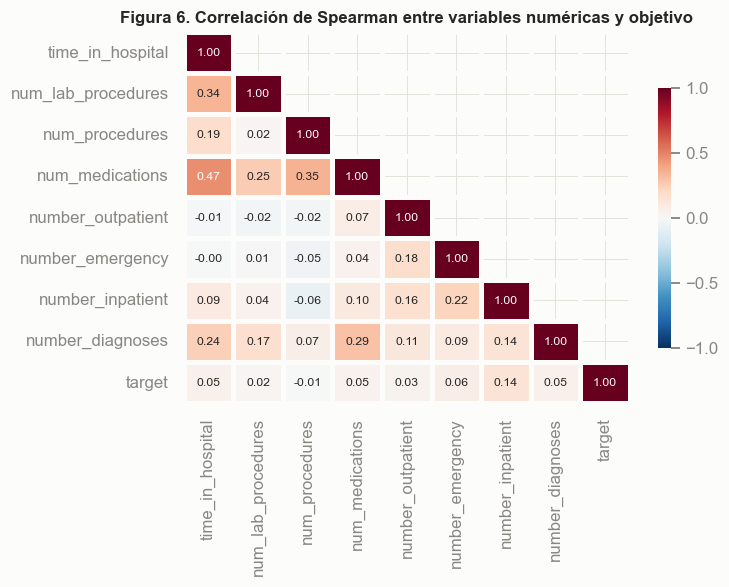

In [14]:
fig, ax = plt.subplots(figsize=(7, 5.5))
corr = df[NUM_RAW + ["target"]].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=2, linecolor="#fcfcfb", cbar_kws={"shrink": 0.7}, ax=ax, annot_kws={"size": 8})
ax.set_title("Figura 6. Correlación de Spearman entre variables numéricas y objetivo")
plt.tight_layout(); plt.show()

**Insights**
- La señal univariada más fuerte es `number_inpatient` (hospitalizaciones en el año previo): el riesgo crece de forma casi monótona. Le siguen `number_emergency`, `number_diagnoses` y `time_in_hospital`.
- `discharge_disposition` es la categórica más asociada: altas a centros de enfermería (SNF) o a otras instituciones tienen tasas de reingreso mucho mayores que el alta a casa.
- El riesgo aumenta con la edad hasta ~80 años; `A1Cresult` y `max_glu_serum` tienen asociación débil pero la **ausencia de medición** es informativa.
- Las correlaciones entre numéricas son moderadas (máx. `num_medications`–`time_in_hospital`), sin multicolinealidad severa.
- Ninguna variable aislada discrimina fuertemente (AUC univariado < 0.62): el problema requiere combinar señales → justifica modelos multivariados y no lineales.

## 4. EDA temporal: evolución de las variables

### 4.1 Tasa de reingreso por periodo (prior shift)

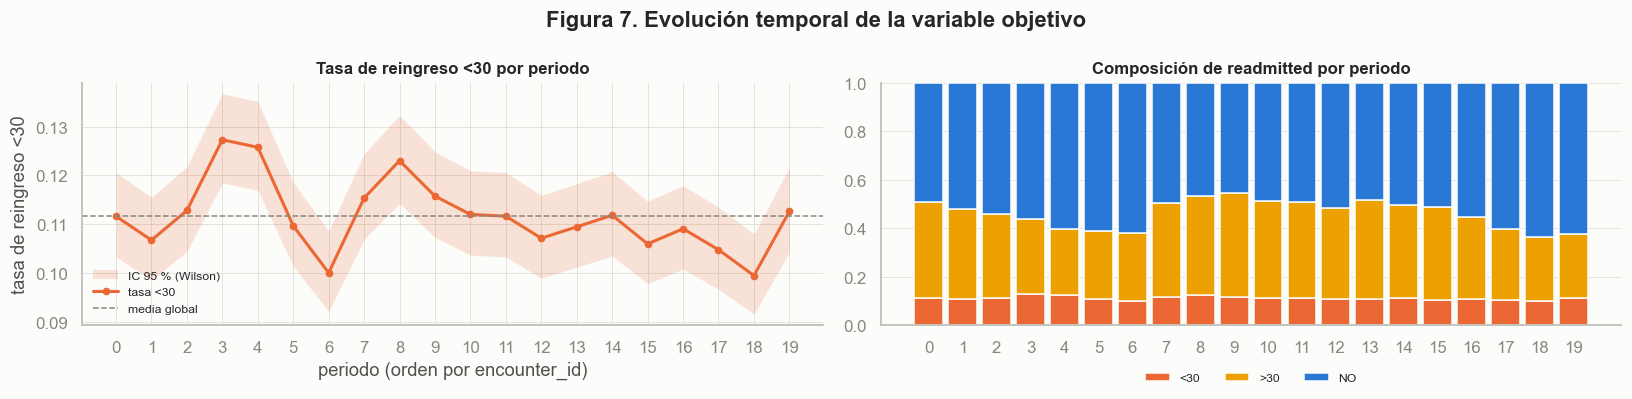

χ² homogeneidad de la tasa <30 entre periodos: χ²=53.0, p=4.64e-05
Rango de la tasa por periodo: 9.94% – 12.73%


In [15]:
def wilson_ci(k, n, z=1.96):
    p = k / n
    den = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return center - half, center + half

tr = df.groupby("period")["target"].agg(k="sum", n="size")
tr["rate"] = tr.k / tr.n
tr["lo"], tr["hi"] = wilson_ci(tr.k, tr.n)
comp = pd.crosstab(df.period, df.readmitted, normalize="index")[["<30", ">30", "NO"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
ax = axes[0]
ax.fill_between(tr.index, tr.lo, tr.hi, color=C2, alpha=0.18, lw=0, label="IC 95 % (Wilson)")
ax.plot(tr.index, tr.rate, color=C2, marker="o", ms=4, label="tasa <30")
ax.axhline(df.target.mean(), color=MUTED, ls="--", lw=1, label="media global")
ax.set_xlabel("periodo (orden por encounter_id)"); ax.set_ylabel("tasa de reingreso <30")
ax.set_title("Tasa de reingreso <30 por periodo"); ax.legend(loc="lower left", fontsize=8)
ax.set_xticks(range(N_PERIODS))
ax = axes[1]
bottom = np.zeros(N_PERIODS)
for col, c in zip(comp.columns, [C2, C4, C1]):
    ax.bar(comp.index, comp[col], bottom=bottom, color=c, label=col, width=0.85, edgecolor="#fcfcfb", lw=1)
    bottom += comp[col].values
ax.set_ylim(0, 1); ax.set_title("Composición de readmitted por periodo"); ax.set_xticks(range(N_PERIODS))
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.15), fontsize=8)
fig.suptitle("Figura 7. Evolución temporal de la variable objetivo", fontweight="bold")
plt.tight_layout(); plt.show()

chi2, p, *_ = stats.chi2_contingency(pd.crosstab(df.period, df.target))
print(f"χ² homogeneidad de la tasa <30 entre periodos: χ²={chi2:.1f}, p={p:.2e}")
print(f"Rango de la tasa por periodo: {tr.rate.min():.2%} – {tr.rate.max():.2%}")

### 4.2 Evolución de las variables numéricas (covariate shift)
Se muestra el **cambio relativo de la media** de cada variable respecto del periodo 0, y la evolución con **ventana deslizante** de 3 000 encuentros.

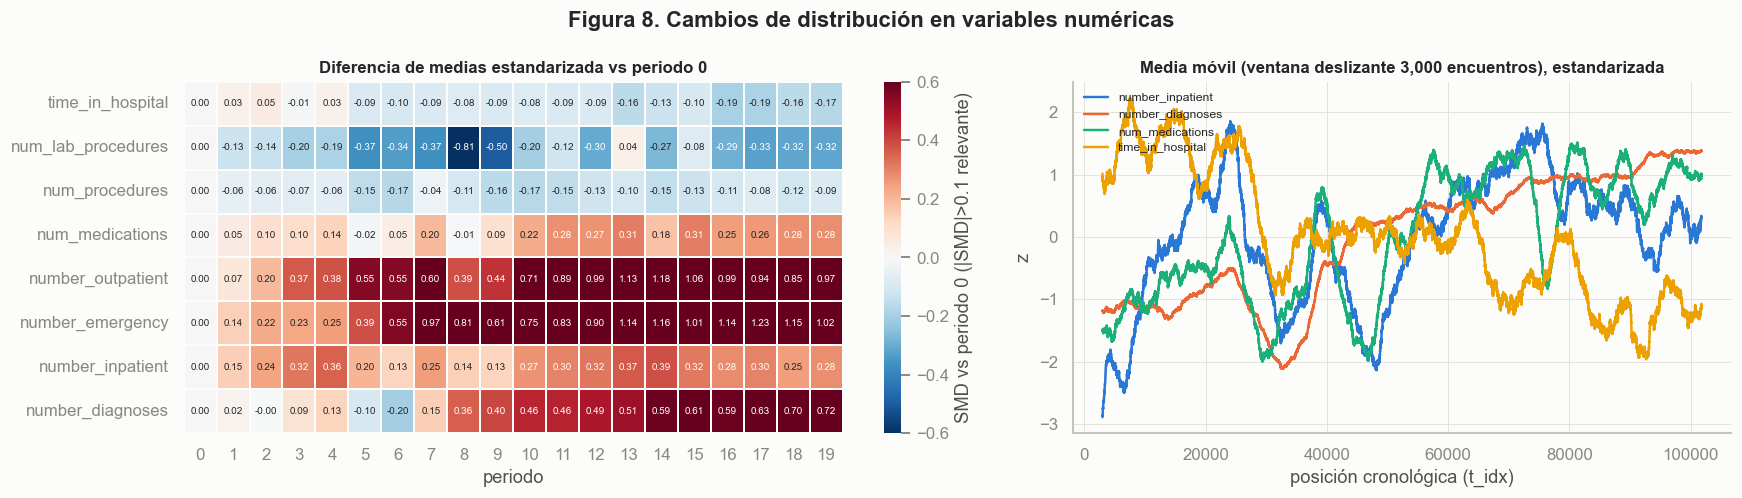

In [16]:
num_means = df.groupby("period")[NUM_RAW].mean()
ref_std = df.loc[df.period == 0, NUM_RAW].std()
smd = (num_means - num_means.iloc[0]) / ref_std   # diferencia de medias estandarizada (SMD)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.25, 1]})
sns.heatmap(smd.T, cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6, annot=True, fmt=".2f",
            annot_kws={"size": 6.5}, linewidths=1, linecolor="#fcfcfb", ax=axes[0],
            cbar_kws={"label": "SMD vs periodo 0 (|SMD|>0.1 relevante)"})
axes[0].set_title("Diferencia de medias estandarizada vs periodo 0"); axes[0].set_xlabel("periodo")

ROLL_W = 3000
roll = df[["number_inpatient", "number_diagnoses", "num_medications", "time_in_hospital"]].rolling(ROLL_W).mean()
roll_z = (roll - roll.mean()) / roll.std()
for col, c in zip(roll_z.columns, [C1, C2, C3, C4]):
    axes[1].plot(df.t_idx, roll_z[col], color=c, lw=1.6, label=col)
axes[1].set_title(f"Media móvil (ventana deslizante {ROLL_W:,} encuentros), estandarizada")
axes[1].set_xlabel("posición cronológica (t_idx)"); axes[1].set_ylabel("z")
axes[1].legend(fontsize=8, loc="upper left")
fig.suptitle("Figura 8. Cambios de distribución en variables numéricas", fontweight="bold")
plt.tight_layout(); plt.show()

### 4.3 Evolución de variables categóricas, práctica clínica y registro

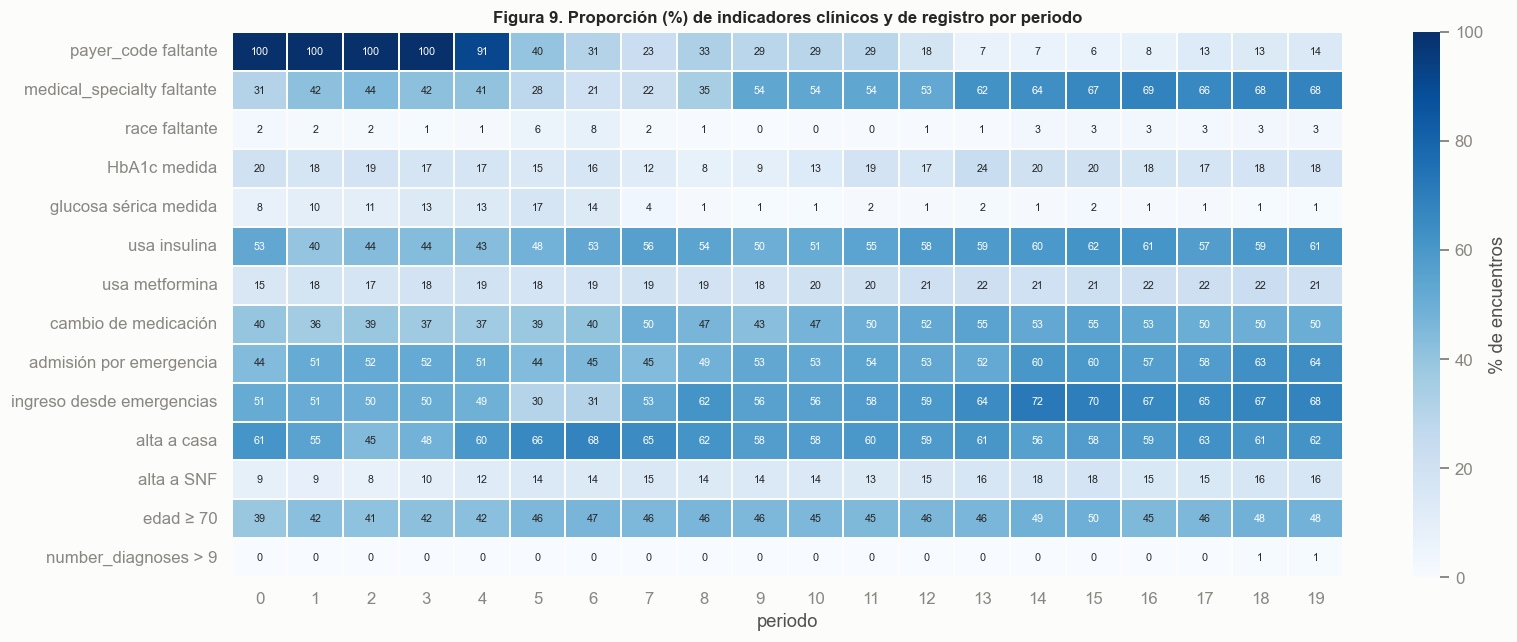

In [17]:
indicators = pd.DataFrame({
    "payer_code faltante": df.payer_code.isna(),
    "medical_specialty faltante": df.medical_specialty.isna(),
    "race faltante": df.race.isna(),
    "HbA1c medida": df.A1Cresult != "None",
    "glucosa sérica medida": df.max_glu_serum != "None",
    "usa insulina": df.insulin != "No",
    "usa metformina": df.metformin != "No",
    "cambio de medicación": df.change == "Ch",
    "admisión por emergencia": df.admission_type_id == 1,
    "ingreso desde emergencias": df.admission_source_id == 7,
    "alta a casa": df.discharge_disposition_id == 1,
    "alta a SNF": df.discharge_disposition_id == 3,
    "edad ≥ 70": df.age.isin(["[70-80)", "[80-90)", "[90-100)"]),
    "number_diagnoses > 9": df.number_diagnoses > 9,
    "period": df.period,
}).groupby("period").mean() * 100

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(indicators.T, cmap="Blues", annot=True, fmt=".0f", annot_kws={"size": 7},
            linewidths=1, linecolor="#fcfcfb", cbar_kws={"label": "% de encuentros"}, ax=ax)
ax.set_title("Figura 9. Proporción (%) de indicadores clínicos y de registro por periodo")
ax.set_xlabel("periodo")
plt.tight_layout(); plt.show()

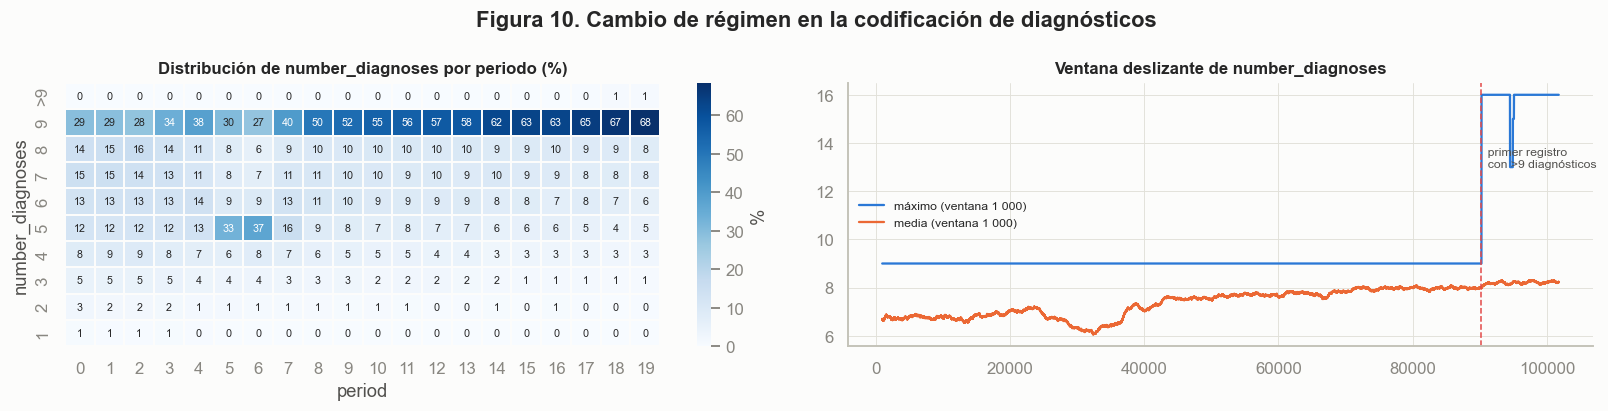

Primer encuentro con >9 diagnósticos: t_idx=90,254 (periodo 17)


In [18]:
# Distribución completa de number_diagnoses por periodo: cambio de régimen de codificación
nd = pd.crosstab(df.period, df.number_diagnoses.clip(upper=10).replace({10: ">9"}).astype(str), normalize="index")
nd = nd[[str(i) for i in range(1, 10)] + [">9"]]
fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
sns.heatmap(nd.T * 100, cmap="Blues", annot=True, fmt=".0f", annot_kws={"size": 7}, ax=axes[0],
            linewidths=1, linecolor="#fcfcfb", cbar_kws={"label": "%"})
axes[0].invert_yaxis(); axes[0].set_title("Distribución de number_diagnoses por periodo (%)")
first_gt9 = df.loc[df.number_diagnoses > 9, "t_idx"].min()
axes[1].plot(df.t_idx, df.number_diagnoses.rolling(1000).max(), color=C1, lw=1.5, label="máximo (ventana 1 000)")
axes[1].plot(df.t_idx, df.number_diagnoses.rolling(1000).mean(), color=C2, lw=1.5, label="media (ventana 1 000)")
axes[1].axvline(first_gt9, color=C8, ls="--", lw=1)
axes[1].text(first_gt9, 13, "  primer registro\n  con >9 diagnósticos", color=INK2, fontsize=8)
axes[1].set_title("Ventana deslizante de number_diagnoses"); axes[1].legend(fontsize=8, loc="center left")
fig.suptitle("Figura 10. Cambio de régimen en la codificación de diagnósticos", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Primer encuentro con >9 diagnósticos: t_idx={first_gt9:,} (periodo {df.loc[first_gt9, 'period']})")

### 4.4 ¿Cambia la relación entre variables y reingreso? (concept drift $P(y\mid X)$)
Si la tasa de reingreso **dentro del mismo subgrupo** cambia con el tiempo, un modelo entrenado en el pasado queda desactualizado aunque $P(X)$ no cambie.

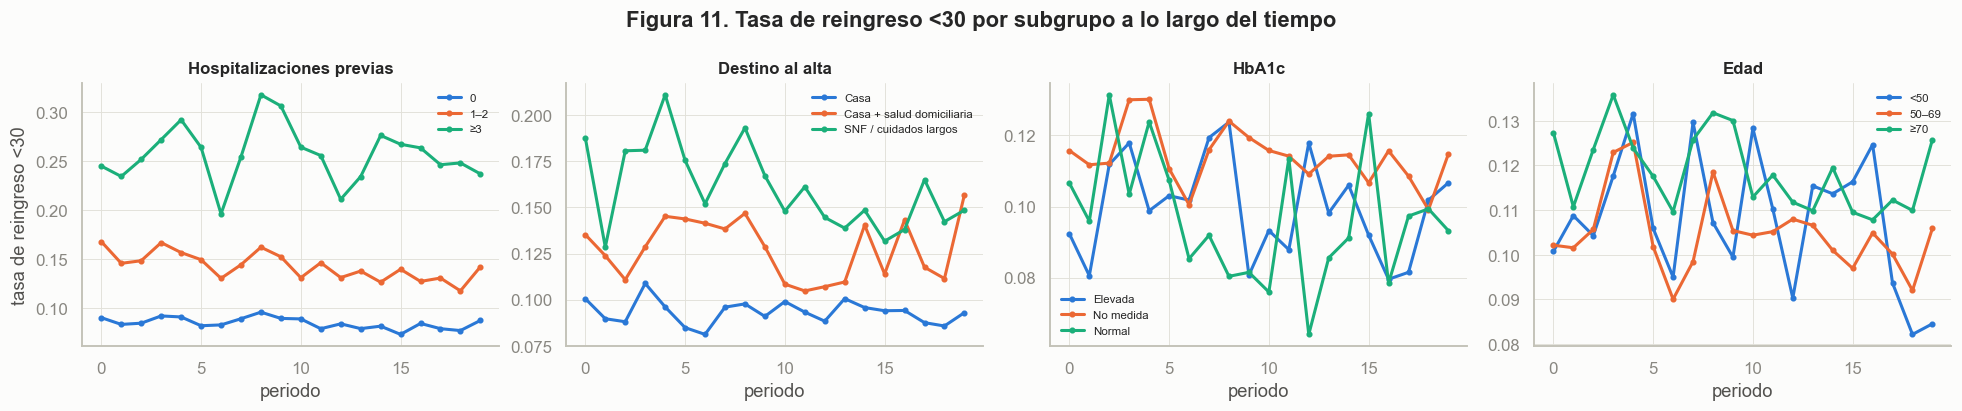

Interacción (hospitalización previa × segunda mitad del periodo):


                Coef.  P>|z|
prev_inp       0.7862 0.0000
half          -0.0863 0.0019
prev_inp:half -0.0296 0.4620


In [19]:
subgroups = {
    "Hospitalizaciones previas": pd.cut(df.number_inpatient, [-1, 0, 2, 100], labels=["0", "1–2", "≥3"]),
    "Destino al alta": np.select([df.discharge_disposition_id == 1, df.discharge_disposition_id.isin([3, 4, 22, 23, 24]),
                                  df.discharge_disposition_id == 6], ["Casa", "SNF / cuidados largos", "Casa + salud domiciliaria"], "Otro"),
    "HbA1c": np.where(df.A1Cresult == "None", "No medida", np.where(df.A1Cresult == "Norm", "Normal", "Elevada")),
    "Edad": pd.cut(df.age.str.extract(r"(\d+)")[0].astype(int), [-1, 49, 69, 100], labels=["<50", "50–69", "≥70"]),
}
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=False)
for ax, (name, grp) in zip(axes, subgroups.items()):
    t = df.assign(g=grp).query("g != 'Otro'").groupby(["period", "g"], observed=True)["target"].mean().unstack()
    for col, c in zip(t.columns, [C1, C2, C3]):
        ax.plot(t.index, t[col], color=c, marker="o", ms=3, label=str(col))
    ax.set_title(name); ax.set_xlabel("periodo"); ax.legend(fontsize=7.5)
axes[0].set_ylabel("tasa de reingreso <30")
fig.suptitle("Figura 11. Tasa de reingreso <30 por subgrupo a lo largo del tiempo", fontweight="bold")
plt.tight_layout(); plt.show()

# Test formal: interacción periodo × subgrupo en regresión logística (statsmodels)
import statsmodels.formula.api as smf
tmp = df.assign(prev_inp=(df.number_inpatient > 0).astype(int), half=(df.period >= N_PERIODS // 2).astype(int))
m = smf.logit("target ~ prev_inp * half", data=tmp).fit(disp=0)
print("Interacción (hospitalización previa × segunda mitad del periodo):")
print(m.summary2().tables[1].loc[["prev_inp", "half", "prev_inp:half"], ["Coef.", "P>|z|"]])

**Insights del EDA temporal:**
- **Prior shift moderado pero significativo:** la tasa de reingreso <30 fluctúa entre ≈9.9 % y 12.7 % por periodo (χ² de homogeneidad p < 0.001), con picos en la primera mitad y valores algo menores en la segunda.
- **Covariate shift fuerte en variables de registro:** `payer_code` pasa de estar 100 % ausente en los periodos 0–3 a faltar solo ~10 % al final; `medical_specialty` faltante sube de ~30 % a ~68 %. Son cambios del **sistema de información**, no de los pacientes → peligrosos si el modelo aprende "faltante = riesgo".
- **Cambio de régimen de codificación:** `number_diagnoses` sube de forma sostenida (SMD creciente) y desde el periodo 17 aparecen por primera vez encuentros con más de 9 diagnósticos (máximo 16). Se armoniza en preprocesamiento.
- **Cambio de práctica y de mezcla de pacientes:** el uso de insulina pasa de ~40 % a ~60 %, aumentan los ingresos por emergencias y las altas a SNF, y la glucosa sérica casi deja de medirse.
- **Relación variable–objetivo:** el efecto de las hospitalizaciones previas es muy fuerte pero **relativamente estable** (la interacción con el tiempo no es significativa, p ≈ 0.46); otros subgrupos (destino al alta, HbA1c) fluctúan más. El *concept drift* esperable es por tanto **gradual y multivariado**, y deberá confirmarse en la etapa de modelado midiendo la degradación del desempeño por periodo.

## 5. Detección estadística de cambios de distribución

Hemos escogido como referencia **periodos 0–3** (primer 20 % de los datos, la ventana con la que se entrenaría un sistema inicial). Cada periodo posterior se compara contra la referencia con:
- **PSI** (*Population Stability Index*): < 0.1 estable · 0.1–0.25 cambio moderado · > 0.25 cambio significativo.
- **Kolmogorov–Smirnov** (numéricas) y **χ²** (categóricas) con corrección de Bonferroni.
- **Clasificador de dominio:** si un modelo distingue referencia vs. periodo reciente (AUC > 0.5), hay covariate shift; sus importancias indican qué variables cambian.
- **Page-Hinkley** sobre el flujo de datos para localizar el punto de cambio.

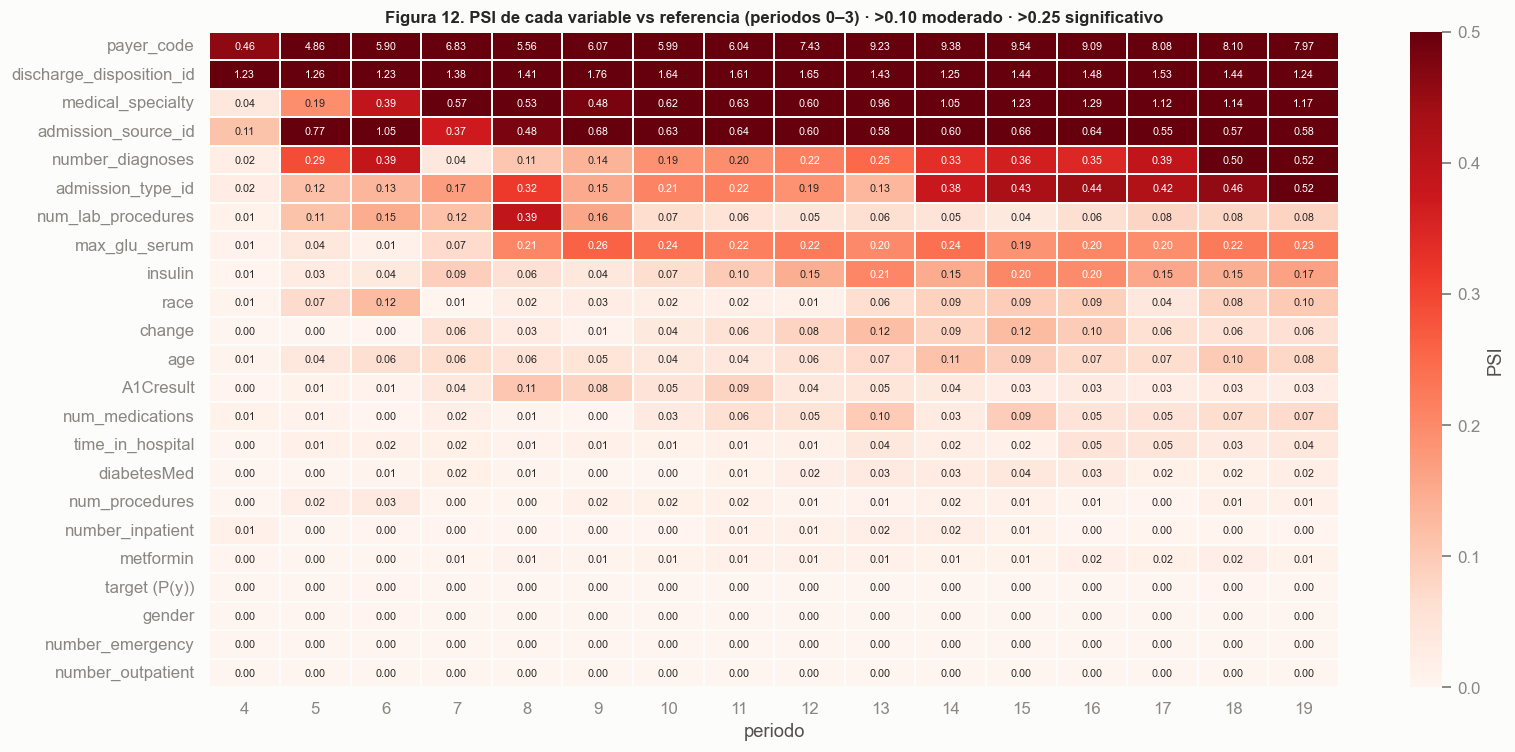

In [20]:
def psi_numeric(ref, cur, bins=10, eps=1e-4):
    edges = np.unique(np.quantile(ref.dropna(), np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    r = np.histogram(ref.dropna(), edges)[0] / ref.notna().sum()
    c = np.histogram(cur.dropna(), edges)[0] / cur.notna().sum()
    r, c = np.clip(r, eps, None), np.clip(c, eps, None)
    return float(np.sum((c - r) * np.log(c / r)))

def psi_categorical(ref, cur, eps=1e-4):
    r = ref.fillna("Missing").value_counts(normalize=True)
    c = cur.fillna("Missing").value_counts(normalize=True)
    idx = r.index.union(c.index)
    r, c = r.reindex(idx, fill_value=0).clip(eps), c.reindex(idx, fill_value=0).clip(eps)
    return float(np.sum((c - r) * np.log(c / r)))

DRIFT_CAT = ["race", "gender", "age", "admission_type_id", "discharge_disposition_id", "admission_source_id",
             "payer_code", "medical_specialty", "max_glu_serum", "A1Cresult", "insulin", "metformin",
             "change", "diabetesMed"]
REF_PERIODS = range(0, 4)
ref = df[df.period.isin(REF_PERIODS)]

psi_rows, test_rows = {}, []
n_tests = (len(NUM_RAW) + len(DRIFT_CAT)) * (N_PERIODS - len(REF_PERIODS))
for p in range(len(REF_PERIODS), N_PERIODS):
    cur = df[df.period == p]
    row = {}
    for c in NUM_RAW:
        row[c] = psi_numeric(ref[c], cur[c])
        test_rows.append((p, c, "KS", stats.ks_2samp(ref[c], cur[c]).pvalue))
    for c in DRIFT_CAT:
        row[c] = psi_categorical(ref[c], cur[c])
        ct = pd.crosstab(pd.concat([ref[c], cur[c]]).fillna("Missing"),
                         np.r_[np.zeros(len(ref)), np.ones(len(cur))])
        test_rows.append((p, c, "chi2", stats.chi2_contingency(ct)[1]))
    row["target (P(y))"] = psi_categorical(ref.target, cur.target)
    psi_rows[p] = row
psi_table = pd.DataFrame(psi_rows)
tests = pd.DataFrame(test_rows, columns=["period", "variable", "test", "p_value"])
tests["drift_bonferroni"] = tests.p_value < 0.05 / n_tests

order = psi_table.max(axis=1).sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(psi_table.loc[order], cmap="Reds", vmin=0, vmax=0.5, annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=1, linecolor="#fcfcfb", cbar_kws={"label": "PSI"}, ax=ax)
ax.set_title("Figura 12. PSI de cada variable vs referencia (periodos 0–3) · >0.10 moderado · >0.25 significativo")
ax.set_xlabel("periodo")
plt.tight_layout(); plt.show()

In [21]:
drift_summary = pd.DataFrame({
    "PSI_max": psi_table.max(axis=1),
    "PSI_ultimo_periodo": psi_table.iloc[:, -1],
    "periodos_PSI>0.10": (psi_table > 0.10).sum(axis=1),
    "periodos_PSI>0.25": (psi_table > 0.25).sum(axis=1),
}).join(tests.groupby("variable")["drift_bonferroni"].sum().rename("periodos_test_significativo"))
drift_summary["nivel"] = pd.cut(drift_summary.PSI_max, [-1, 0.1, 0.25, np.inf], labels=["estable", "moderado", "significativo"])
drift_summary.sort_values("PSI_max", ascending=False)

,PSI_max,PSI_ultimo_periodo,periodos_PSI>0.10,periodos_PSI>0.25,periodos_test_significativo,nivel
payer_code,9.5401,7.9702,16,16,16.0000,significativo
discharge_disposition_id,1.7567,1.2388,16,16,16.0000,significativo
medical_specialty,1.2914,1.1729,15,14,16.0000,significativo
admission_source_id,1.0531,0.5830,16,15,16.0000,significativo
number_diagnoses,0.5219,0.5219,14,9,16.0000,significativo
admission_type_id,0.5155,0.5155,15,7,16.0000,significativo
num_lab_procedures,0.3933,0.0838,5,1,16.0000,significativo
max_glu_serum,0.2601,0.2264,12,1,16.0000,significativo
insulin,0.2054,0.1657,9,0,16.0000,moderado
race,0.1239,0.1009,2,0,15.0000,moderado


AUC del clasificador de dominio (referencia vs reciente): 0.993  (0.5 = sin cambio)


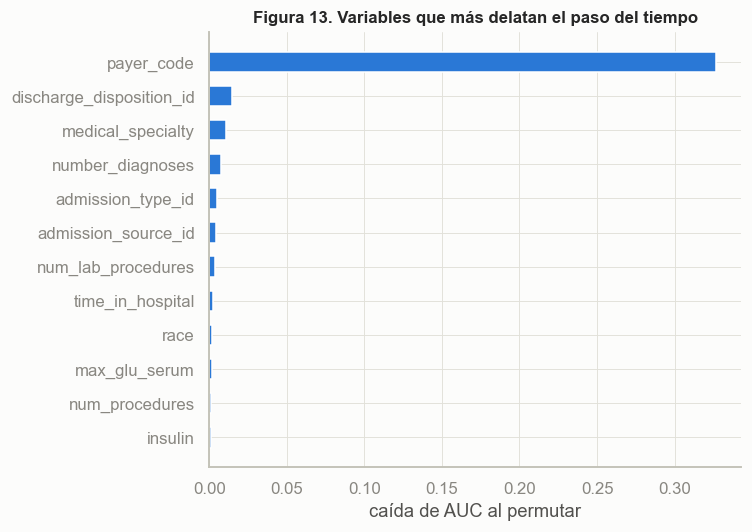

In [22]:
# Clasificador de dominio: referencia inicial (periodos 0-3) vs final (periodos 16-19)
dom_feats = NUM_RAW + DRIFT_CAT
dom = df[df.period.isin(list(REF_PERIODS) + list(range(16, 20)))].copy()
dom["is_recent"] = (dom.period >= 16).astype(int)
Xd = dom[dom_feats].copy()
for c in DRIFT_CAT:
    Xd[c] = Xd[c].astype(str).astype("category")
dom_tr = dom.sample(frac=0.7, random_state=SEED).index
dom_te = dom.index.difference(dom_tr)
dclf = HistGradientBoostingClassifier(max_iter=150, categorical_features="from_dtype", random_state=SEED)
dclf.fit(Xd.loc[dom_tr], dom.loc[dom_tr, "is_recent"])
dom_auc = roc_auc_score(dom.loc[dom_te, "is_recent"], dclf.predict_proba(Xd.loc[dom_te])[:, 1])
print(f"AUC del clasificador de dominio (referencia vs reciente): {dom_auc:.3f}  (0.5 = sin cambio)")

pi = permutation_importance(dclf, Xd.loc[dom_te].sample(6000, random_state=SEED),
                            dom.loc[dom_te, "is_recent"].sample(6000, random_state=SEED),
                            scoring="roc_auc", n_repeats=3, random_state=SEED)
dom_imp = pd.Series(pi.importances_mean, index=dom_feats).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(dom_imp.index[-12:], dom_imp.values[-12:], color=C1, height=0.6)
ax.set_xlabel("caída de AUC al permutar"); ax.set_title("Figura 13. Variables que más delatan el paso del tiempo")
plt.tight_layout(); plt.show()

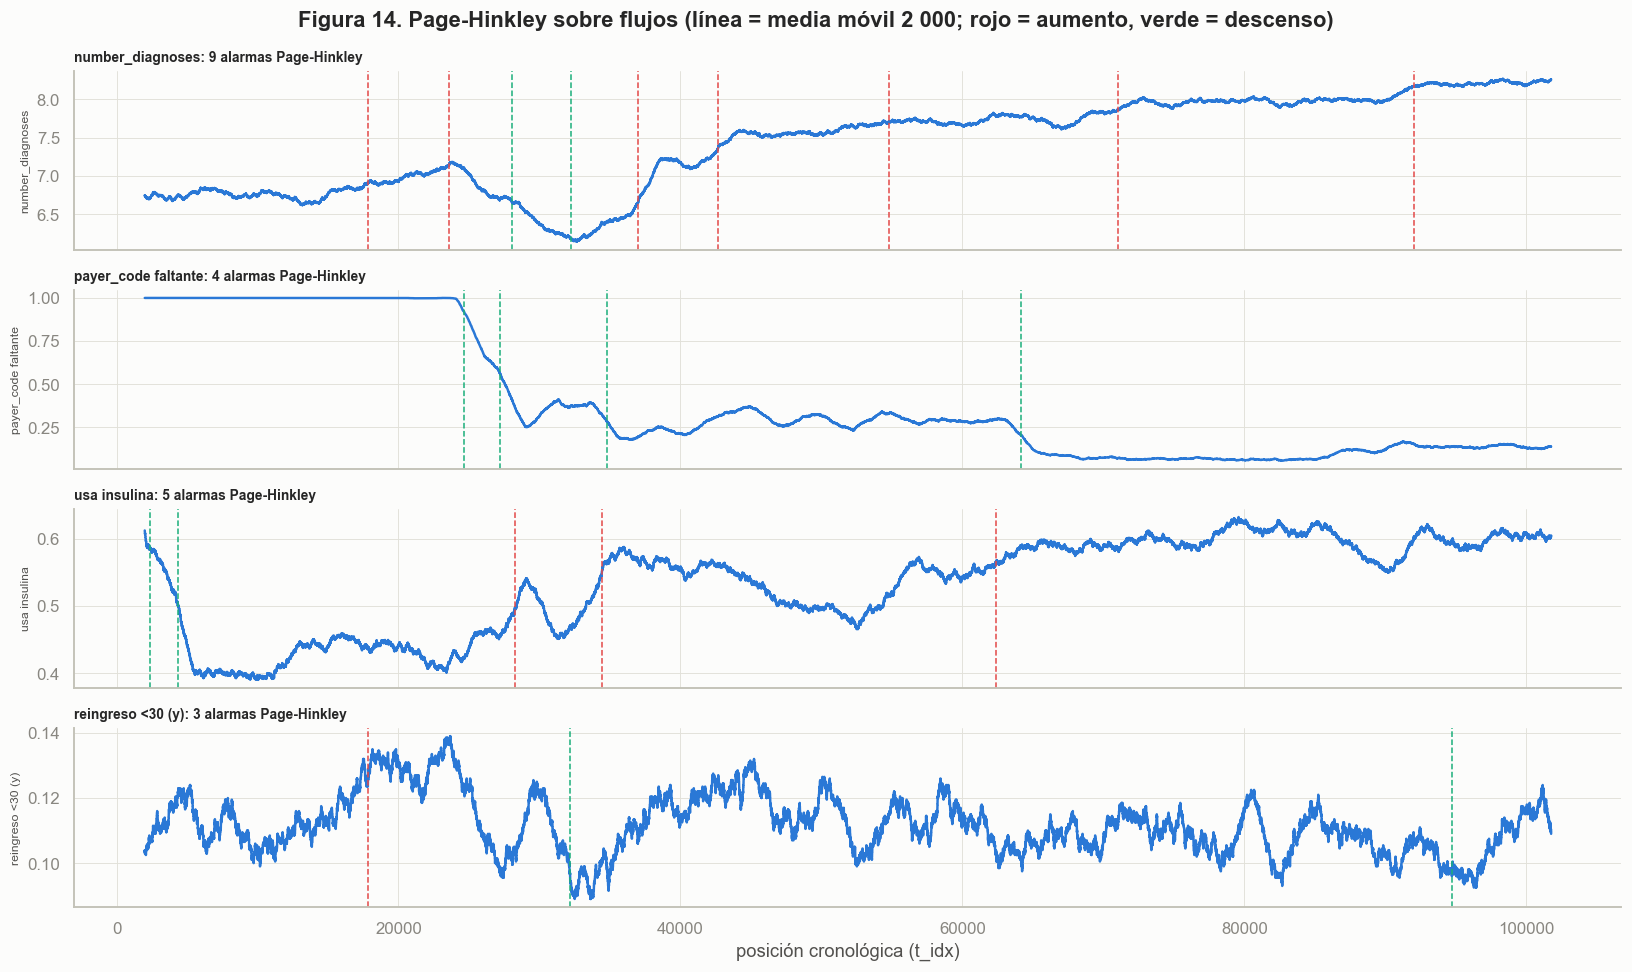

number_diagnoses       alarmas en periodos: [3, 4, 5, 6, 7, 8, 10, 13, 18]
payer_code faltante    alarmas en periodos: [4, 5, 6, 12]
usa insulina           alarmas en periodos: [0, 5, 6, 12]
reingreso <30 (y)      alarmas en periodos: [3, 6, 18]


In [23]:
class PageHinkley:
    # Detector de cambio en la media de un flujo (incrementos); usar -x para detectar descensos
    def __init__(self, delta=0.005, threshold=50.0, min_n=500):
        self.delta, self.threshold, self.min_n = delta, threshold, min_n
        self.reset()

    def reset(self):
        self.n, self.mean, self.cum, self.min_cum = 0, 0.0, 0.0, 0.0

    def update(self, x):
        self.n += 1
        self.mean += (x - self.mean) / self.n
        self.cum += x - self.mean - self.delta
        self.min_cum = min(self.min_cum, self.cum)
        if self.n >= self.min_n and self.cum - self.min_cum > self.threshold:
            self.reset()
            return True
        return False

def run_page_hinkley(values, **kw):
    up, down = PageHinkley(**kw), PageHinkley(**kw)
    alarms = []
    for i, v in enumerate(values):
        if up.update(v):
            alarms.append((i, "↑"))
        if down.update(-v):
            alarms.append((i, "↓"))
    return alarms

streams = {
    "number_diagnoses": (df.number_diagnoses.values, dict(delta=0.05, threshold=300)),
    "payer_code faltante": (df.payer_code.isna().astype(float).values, dict(delta=0.01, threshold=150)),
    "usa insulina": (df.insulin.ne("No").astype(float).values, dict(delta=0.01, threshold=100)),
    "reingreso <30 (y)": (df.target.astype(float).values, dict(delta=0.005, threshold=40)),
}
fig, axes = plt.subplots(len(streams), 1, figsize=(15, 9), sharex=True)
ph_alarms = {}
for ax, (name, (vals, kw)) in zip(axes, streams.items()):
    alarms = run_page_hinkley(vals, **kw)
    ph_alarms[name] = alarms
    ax.plot(df.t_idx, pd.Series(vals).rolling(2000).mean(), color=C1, lw=1.6)
    for i, direction in alarms:
        ax.axvline(i, color=C8 if direction == "↑" else C3, ls="--", lw=1)
    ax.set_ylabel(name, fontsize=8); ax.set_title(f"{name}: {len(alarms)} alarmas Page-Hinkley", fontsize=9, loc="left")
axes[-1].set_xlabel("posición cronológica (t_idx)")
fig.suptitle("Figura 14. Page-Hinkley sobre flujos (línea = media móvil 2 000; rojo = aumento, verde = descenso)",
             fontweight="bold")
plt.tight_layout(); plt.show()
for k, v in ph_alarms.items():
    print(f"{k:22s} alarmas en periodos: {sorted({int(df.period.iloc[i]) for i, _ in v})}")

**Insights de drift:**
- **Drift significativo (PSI > 0.25)** en variables de **registro y codificación administrativa**: `payer_code` (PSI ≈ 9.5), `discharge_disposition_id`, `medical_specialty`, `admission_source_id`, `admission_type_id` y `number_diagnoses`.
- **Drift moderado** en `max_glu_serum`, `insulin`, `num_lab_procedures`; las variables de utilización previa (`number_inpatient`, `number_emergency`, `number_outpatient`) son **estables**.
- La variable objetivo tiene PSI muy bajo (< 0.01): el prior shift es pequeño en magnitud aunque estadísticamente detectable.
- El clasificador de dominio separa referencia y periodo reciente con AUC ≈ 0.99 → **los datos de entrenamiento iniciales no son representativos del futuro**. Se viola el supuesto i.i.d.
- Page-Hinkley localiza puntos de cambio concretos, útiles como disparadores de reentrenamiento en la etapa de adaptación.

**Implicaciones para el preprocesamiento:** no confiar en indicadores de faltante que dependen del sistema de registro, armonizar `number_diagnoses`, y adaptar el modelo con ventanas deslizantes.

## 6. Detección de anomalías
Tres niveles: 
- (1) valores extremos univariados 
- (2) anomalías multivariadas con Isolation Forest y su evolución temporal
- (3) inconsistencias lógicas.

In [24]:
def iqr_outliers(s, k=3.0):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

out_tbl = pd.DataFrame({
    "%_outliers_IQR(k=3)": [iqr_outliers(df[c]).mean() * 100 for c in NUM_RAW],
    "%_|z|>4": [(np.abs(stats.zscore(df[c])) > 4).mean() * 100 for c in NUM_RAW],
    "max": [df[c].max() for c in NUM_RAW],
    "p99": [df[c].quantile(0.99) for c in NUM_RAW],
    "tasa_<30_outliers": [df.loc[iqr_outliers(df[c]), "target"].mean() for c in NUM_RAW],
}, index=NUM_RAW)
out_tbl

,%_outliers_IQR(k=3),%_|z|>4,max,p99,tasa_<30_outliers
time_in_hospital,0.0000,0.0000,14,14.0000,NaN
num_lab_procedures,0.0000,0.0029,132,85.0000,NaN
num_procedures,0.0000,0.0000,6,6.0000,NaN
num_medications,0.4225,0.5365,81,43.0000,0.1070
number_outpatient,16.4485,0.9080,42,5.0000,0.1363
number_emergency,11.1855,0.9227,76,3.0000,0.1660
number_inpatient,1.9810,1.1831,21,6.0000,0.3641
number_diagnoses,0.0000,0.0442,16,9.0000,NaN


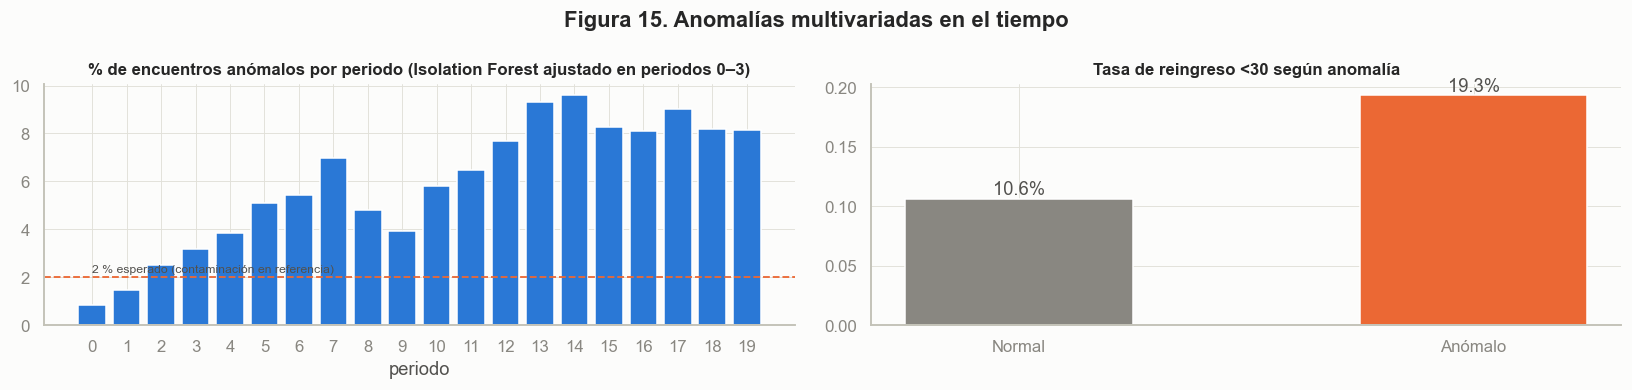

In [25]:
iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=SEED)
iso.fit(ref[NUM_RAW])
df["anomaly_score"] = -iso.score_samples(df[NUM_RAW])
df["is_anomaly"] = iso.predict(df[NUM_RAW]) == -1

an = df.groupby("period").agg(pct_anom=("is_anomaly", "mean"), score=("anomaly_score", "mean"))
fig, axes = plt.subplots(1, 2, figsize=(15, 3.6))
axes[0].bar(an.index, an.pct_anom * 100, color=C1, width=0.8)
axes[0].axhline(2, color=C2, ls="--", lw=1.2)
axes[0].text(0, 2.1, "2 % esperado (contaminación en referencia)", color=INK2, fontsize=8, va="bottom")
axes[0].set_title("% de encuentros anómalos por periodo (Isolation Forest ajustado en periodos 0–3)")
axes[0].set_xlabel("periodo"); axes[0].set_xticks(range(N_PERIODS))
ar = df.groupby("is_anomaly")["target"].mean()
b = axes[1].bar(["Normal", "Anómalo"], ar.values, color=[MUTED, C2], width=0.5)
axes[1].bar_label(b, labels=[f"{v:.1%}" for v in ar.values], color=INK2)
axes[1].set_title("Tasa de reingreso <30 según anomalía")
fig.suptitle("Figura 15. Anomalías multivariadas en el tiempo", fontweight="bold")
plt.tight_layout(); plt.show()

In [26]:
g = df.groupby("patient_nbr")
prev_label = g["readmitted"].shift(1)
inconsist = {
    "Alta por fallecimiento/hospicio con readmitted ≠ NO": (df.discharge_disposition_id.isin(EXPIRED_HOSPICE) & (df.readmitted != "NO")).sum(),
    "Encuentro previo del paciente etiquetado 'NO' pese a existir reingreso posterior": (prev_label == "NO").sum(),
    "Admisión 'Newborn' en pacientes > 10 años": ((df.admission_type_id == 4) & (df.age != "[0-10)")).sum(),
    "Paciente con encuentros de distinto sexo": (g["gender"].transform("nunique") > 1).sum(),
    "Paciente con edad que disminuye en el tiempo": (g["age"].transform(lambda s: s.str.extract(r"(\d+)")[0].astype(int).diff().lt(0).any())).sum(),
    "number_diagnoses > 9 (régimen nuevo)": (df.number_diagnoses > 9).sum(),
    "Pacientes pediátricos (< 20 años)": df.age.isin(["[0-10)", "[10-20)"]).sum(),
}
pd.Series(inconsist, name="n_registros").to_frame()

,n_registros
Alta por fallecimiento/hospicio con readmitted ≠ NO,86
Encuentro previo del paciente etiquetado 'NO' pese a existir reingreso posterior,490
Admisión 'Newborn' en pacientes > 10 años,9
Paciente con encuentros de distinto sexo,7
Paciente con edad que disminuye en el tiempo,62
number_diagnoses > 9 (régimen nuevo),115
Pacientes pediátricos (< 20 años),852


**Tratamiento de anomalías (decisiones que hemos tomado):**
- Los extremos de conteos (p. ej. `number_outpatient`, `number_emergency`) son **clínicamente plausibles** y tienen tasas de reingreso mayores → no se eliminan; se usa `log1p` para modelos lineales y los árboles son robustos.
- El % de anomalías multivariadas **crece con el tiempo** respecto de la referencia: es otra manifestación del drift, no ruido a eliminar.
- Las inconsistencias lógicas relevantes para la etiqueta (fallecidos/hospicio) se excluyen; las de sexo/edad por paciente son muy pocas y se conservan.
- Encuentros etiquetados `NO` pese a tener un reingreso posterior evidencian **ruido de etiqueta** (≈2 % de pares consecutivos): se documenta como limitación.

## 7. Preprocesamiento

En resumen estas fueron las decisioens que tomamos y el porque de estas deciciones luego de realizar el EDA en todo el dataset
| Decisión | Justificación |
|---|---|
| Excluir altas por fallecimiento/hospicio y sexo inválido | No pueden reingresar / registro inválido (Sección 1) |
| Eliminar `weight`, `examide`, `citoglipton` | 97 % faltante / constantes |
| Eliminar `payer_code` | Drift de registro extremo (PSI > 0.25): de 100 % faltante a mayoritariamente registrado; asociación débil con el objetivo. Aprendería un artefacto del sistema de información |
| Faltantes categóricos → `Missing` | Faltante no aleatorio e informativo |
| IDs de admisión/alta/fuente → grupos clínicos | Reduce cardinalidad y agrupa faltantes ocultos |
| Diagnósticos ICD-9 → 9 grupos (Strack et al., 2014) | ~700 códigos → grupos clínicos interpretables |
| `medical_specialty` → top-15 **del train** + `Other` | Evita categorías raras y fuga (se aprende solo del pasado) |
| `age` → punto medio numérico | Preserva el orden |
| `number_diagnoses` → recortado a 9 | Armoniza el cambio de régimen de codificación (Sección 4.3) |
| `log1p` + estandarización (solo modelo lineal) | Conteos muy asimétricos |
| Medicamentos raros (< 1 % de uso) → solo en conteos agregados | Evita columnas casi constantes |

Todo lo que **aprende de los datos** (top de especialidades, imputación, escalado, codificación) se ajusta **solo con el conjunto de entrenamiento**.

In [27]:
data = df[~df.discharge_disposition_id.isin(EXPIRED_HOSPICE) & (df.gender != "Unknown/Invalid")].copy()
data = data.drop(columns=["weight", "examide", "citoglipton", "payer_code", "anomaly_score", "is_anomaly"])
MEDS = [c for c in MED_COLS if c in data.columns]
print(f"Encuentros tras limpieza: {len(data):,} ({len(data) / len(df):.1%} del total) | tasa <30: {data.target.mean():.2%}")

def map_groups(s, groups, default="Other"):
    lookup = {code: name for name, codes in groups.items() for code in codes}
    return s.map(lookup).fillna(default)

ADM_TYPE_GROUPS = {"Emergency/Urgent": [1, 2, 7], "Elective": [3], "Unknown": [5, 6, 8]}
DISCHARGE_GROUPS = {"Home": [1], "Home health": [6, 8], "SNF/long-term": [3, 4, 5, 15, 22, 23, 24, 27, 29, 30],
                    "Other hospital": [2, 9, 10, 16, 17, 28], "Left AMA": [7], "Unknown": [18, 25, 26]}
ADM_SOURCE_GROUPS = {"Referral": [1, 2, 3], "Emergency room": [7], "Transfer": [4, 5, 6, 10, 18, 22, 25, 26],
                     "Unknown": [9, 15, 17, 20, 21]}

def icd9_group(code):
    if pd.isna(code):
        return "Missing"
    if code[0] in "VE":
        return "Other"
    v = float(code)
    if 390 <= v < 460 or int(v) == 785: return "Circulatory"
    if 460 <= v < 520 or int(v) == 786: return "Respiratory"
    if 520 <= v < 580 or int(v) == 787: return "Digestive"
    if int(v) == 250: return "Diabetes"
    if 800 <= v < 1000: return "Injury"
    if 710 <= v < 740: return "Musculoskeletal"
    if 580 <= v < 630 or int(v) == 788: return "Genitourinary"
    if 140 <= v < 240: return "Neoplasms"
    return "Other"

data["admission_type_grp"] = map_groups(data.admission_type_id, ADM_TYPE_GROUPS)
data["discharge_grp"] = map_groups(data.discharge_disposition_id, DISCHARGE_GROUPS)
data["admission_source_grp"] = map_groups(data.admission_source_id, ADM_SOURCE_GROUPS)
for i in (1, 2, 3):
    data[f"diag_{i}_grp"] = data[f"diag_{i}"].map(icd9_group)
data["race"] = data.race.fillna("Missing")
data["medical_specialty"] = data.medical_specialty.fillna("Missing")
data["age_num"] = data.age.str.extract(r"\[(\d+)-")[0].astype(int) + 5
data["number_diagnoses_capped"] = data.number_diagnoses.clip(upper=9)

data[["admission_type_grp", "discharge_grp", "admission_source_grp", "diag_1_grp"]].apply(
    lambda s: s.value_counts(normalize=True).round(3).to_dict())

Encuentros tras limpieza: 99,340 (97.6% del total) | tasa <30: 11.39%


admission_type_grp      {'Emergency/Urgent': 0.71, 'Elective': 0.188, ...
discharge_grp           {'Home': 0.606, 'SNF/long-term': 0.186, 'Home ...
admission_source_grp    {'Emergency room': 0.562, 'Referral': 0.306, '...
diag_1_grp              {'Circulatory': 0.299, 'Other': 0.179, 'Respir...
dtype: object

## 8. Feature engineering

Tres familias de variables, **todas disponibles al momento del alta**:

1. **Estáticas del encuentro** (derivadas clínicas): utilización de servicios, carga de medicación, comorbilidades.
2. **Temporales por paciente (variables rezagadas / lags):** historial del mismo paciente usando **solo encuentros anteriores** (`shift`, sumas acumuladas y ventanas de los últimos 3 encuentros).
3. **Agregaciones por ventana deslizante (contexto del periodo):** tasas y medias recientes en los últimos 3 000 encuentros, con **embargo por latencia de etiqueta** para las variables que usan el objetivo.

**Latencia de etiqueta.** Si los encuentros se repartieran de forma uniforme habría ≈ 28 encuentros/día (101 766 en ~10 años), y 30 días serían ≈ 840 encuentros; la hipótesis inicial era un embargo de `LABEL_DELAY_NAIVE = 1 000` encuentros (≈ 36 días). La densidad de encuentros **no es constante**, así que el embargo se **calibra empíricamente solo con los periodos de train** a partir de la distancia a la que el siguiente encuentro del paciente deja de ser un reingreso <30 (evidencia y validación en la **Sección 10.3**). Una etiqueta solo se considera conocida `LABEL_DELAY` posiciones después.

**¿El lag de reingreso previo es fuga?** No: si el encuentro anterior del paciente terminó en reingreso <30, ese hecho ya ocurrió (y es observable) cuando el paciente vuelve a ser admitido en el encuentro actual.

In [28]:
LABEL_DELAY_NAIVE = 1000   # hipótesis inicial: ≈ 28 encuentros/día × 36 días (densidad constante)
CTX_W = 3000
data = data.sort_values("t_idx").reset_index(drop=True)

# ---- 0) Calibración empírica de la latencia de etiqueta (evidencia en la Sección 10.3) ----
def next_gap(d):
    # Distancia en pseudo-tiempo al siguiente encuentro del mismo paciente (NaN si no vuelve)
    return d.groupby("patient_nbr", sort=False)["t_idx"].shift(-1) - d.t_idx

def readmission_boundary(gap, y, thr=0.2, step=100, min_gap=500):
    # Equivalente de "30 días" en encuentros: primer tramo de distancia donde P(target=1 | gap) < thr
    rate = y.groupby((gap // step) * step).mean()
    rate = rate[(rate.index >= min_gap) & (rate < thr)]
    return float(rate.index.min()) if len(rate) else np.nan

d_cal = data[data.period <= 11]            # solo periodos de train: el parámetro no mira el futuro
gap_cal = next_gap(d_cal)
delay_by_period = pd.Series({p: readmission_boundary(gap_cal[d_cal.period == p], d_cal.target[d_cal.period == p])
                             for p in range(12)})
LABEL_DELAY = int(np.ceil(delay_by_period.max() / 500) * 500)   # máximo en train, redondeado hacia arriba
print(f"Equivalente de 30 días por periodo de train: {delay_by_period.astype(int).to_dict()}")
print(f"LABEL_DELAY calibrado = {LABEL_DELAY:,} encuentros (hipótesis inicial: {LABEL_DELAY_NAIVE:,})")

# ---- 1) Estáticas ----
data["service_utilization"] = data.number_outpatient + data.number_emergency + data.number_inpatient
data["n_meds_active"] = (data[MEDS] != "No").sum(axis=1)
data["n_meds_changed"] = data[MEDS].isin(["Up", "Down"]).sum(axis=1)
data["meds_per_day"] = data.num_medications / data.time_in_hospital
data["labs_per_day"] = data.num_lab_procedures / data.time_in_hospital
diag_grps = data[["diag_1_grp", "diag_2_grp", "diag_3_grp"]]
data["n_comorbidity_groups"] = diag_grps.apply(lambda r: len(set(r) - {"Missing", "Other"}), axis=1)
data["dm_primary"] = (data.diag_1_grp == "Diabetes").astype(int)
diag_str = data[["diag_1", "diag_2", "diag_3"]].fillna("")
data["dm_complicated"] = diag_str.apply(lambda c: c.str.match(r"^250\.[1-9]")).any(axis=1).astype(int)
data["a1c_tested"] = (data.A1Cresult != "None").astype(int)
data["a1c_high"] = data.A1Cresult.isin([">7", ">8"]).astype(int)
data["glu_tested"] = (data.max_glu_serum != "None").astype(int)
data["glu_high"] = data.max_glu_serum.isin([">200", ">300"]).astype(int)

# ---- 2) Temporales por paciente (solo pasado) ----
g = data.groupby("patient_nbr", sort=False)
data["enc_seq"] = g.cumcount()
data["is_returning"] = (data.enc_seq > 0).astype(int)
data["prev_readmit30"] = g["target"].shift(1).fillna(0)
data["hist_n_readmit30"] = g["target"].cumsum() - data.target
data["hist_rate_readmit30"] = np.where(data.enc_seq > 0, data.hist_n_readmit30 / data.enc_seq.clip(lower=1), 0)
for col in ["time_in_hospital", "num_medications", "number_diagnoses_capped", "n_meds_active"]:
    data[f"prev_{col}"] = g[col].shift(1)
data["delta_num_medications"] = (data.num_medications - data.prev_num_medications).fillna(0)
data["delta_n_meds_active"] = (data.n_meds_active - data.prev_n_meds_active).fillna(0)
lags = np.column_stack([g["time_in_hospital"].shift(k) for k in (1, 2, 3)])
data["roll3_time_in_hospital"] = np.nanmean(np.where(np.isnan(lags), np.nan, lags), axis=1)
data["log_gap_prev_encounter"] = np.log1p(data.t_idx - g["t_idx"].shift(1))  # distancia en pseudo-tiempo
data["prev_discharge_snf"] = g["discharge_grp"].shift(1).eq("SNF/long-term").astype(int)

# ---- 3) Agregaciones por ventana deslizante (contexto) ----
data["ctx_readmit_rate"] = data.target.shift(LABEL_DELAY).rolling(CTX_W, min_periods=500).mean()  # con embargo
data["ctx_inpatient_mean"] = data.number_inpatient.shift(1).rolling(CTX_W, min_periods=500).mean()
data["ctx_a1c_rate"] = data.a1c_tested.shift(1).rolling(CTX_W, min_periods=500).mean()
ctx_ndiag = data.number_diagnoses.shift(1).rolling(CTX_W, min_periods=500).mean()
ctx_nmed = data.num_medications.shift(1).rolling(CTX_W, min_periods=500).mean()
data["rel_number_diagnoses"] = data.number_diagnoses - ctx_ndiag       # relativo al régimen de codificación vigente
data["rel_num_medications"] = data.num_medications - ctx_nmed         # relativo a la práctica reciente

TEMPORAL_FEATS = ["enc_seq", "is_returning", "prev_readmit30", "hist_n_readmit30", "hist_rate_readmit30",
                  "prev_time_in_hospital", "prev_num_medications", "prev_number_diagnoses_capped",
                  "prev_n_meds_active", "delta_num_medications", "delta_n_meds_active", "roll3_time_in_hospital",
                  "log_gap_prev_encounter", "prev_discharge_snf"]
CONTEXT_FEATS = ["ctx_readmit_rate", "ctx_inpatient_mean", "ctx_a1c_rate", "rel_number_diagnoses", "rel_num_medications"]
print(f"Pacientes con historial previo: {data.is_returning.mean():.1%} de los encuentros")
data[TEMPORAL_FEATS + CONTEXT_FEATS].describe().T

Equivalente de 30 días por periodo de train: {0: 900, 1: 1000, 2: 900, 3: 900, 4: 1000, 5: 900, 6: 1000, 7: 800, 8: 1300, 9: 1500, 10: 1600, 11: 1700}
LABEL_DELAY calibrado = 2,000 encuentros (hipótesis inicial: 1,000)


Pacientes con historial previo: 29.5% de los encuentros


,count,mean,std,min,25%,50%,75%,max
enc_seq,"99,340.0000",0.6254,1.5269,0.0000,0.0000,0.0000,1.0000,39.0000
is_returning,"99,340.0000",0.2955,0.4563,0.0000,0.0000,0.0000,1.0000,1.0000
prev_readmit30,"99,340.0000",0.0790,0.2697,0.0000,0.0000,0.0000,0.0000,1.0000
hist_n_readmit30,"99,340.0000",0.1855,0.7185,0.0000,0.0000,0.0000,0.0000,22.0000
hist_rate_readmit30,"99,340.0000",0.0775,0.2357,0.0000,0.0000,0.0000,0.0000,1.0000
prev_time_in_hospital,"29,353.0000",4.5632,2.9831,1.0000,2.0000,4.0000,6.0000,14.0000
prev_num_medications,"29,353.0000",16.3694,7.7302,1.0000,11.0000,15.0000,20.0000,72.0000
prev_number_diagnoses_capped,"29,353.0000",7.6183,1.8119,1.0000,6.0000,9.0000,9.0000,9.0000
prev_n_meds_active,"29,353.0000",1.2068,0.8956,0.0000,1.0000,1.0000,2.0000,6.0000
delta_num_medications,"99,340.0000",0.1057,4.8807,-59.0000,0.0000,0.0000,0.0000,59.0000


In [29]:
# Verificación anti-fuga: las variables rezagadas no deben depender de encuentros futuros.
# Se recalculan truncando los datos en un punto y deben coincidir exactamente con el cálculo completo.
cut = int(len(data) * 0.5)
trunc = data.iloc[:cut].copy()
gt = trunc.groupby("patient_nbr", sort=False)
check = pd.DataFrame({
    "enc_seq": gt.cumcount(),
    "hist_n_readmit30": gt["target"].cumsum() - trunc.target,
    "prev_readmit30": gt["target"].shift(1).fillna(0),
})
ok = all(np.allclose(check[c].values, data.iloc[:cut][c].values) for c in check)
print("Variables rezagadas idénticas con datos truncados (sin fuga del futuro):", ok)

Variables rezagadas idénticas con datos truncados (sin fuga del futuro): True


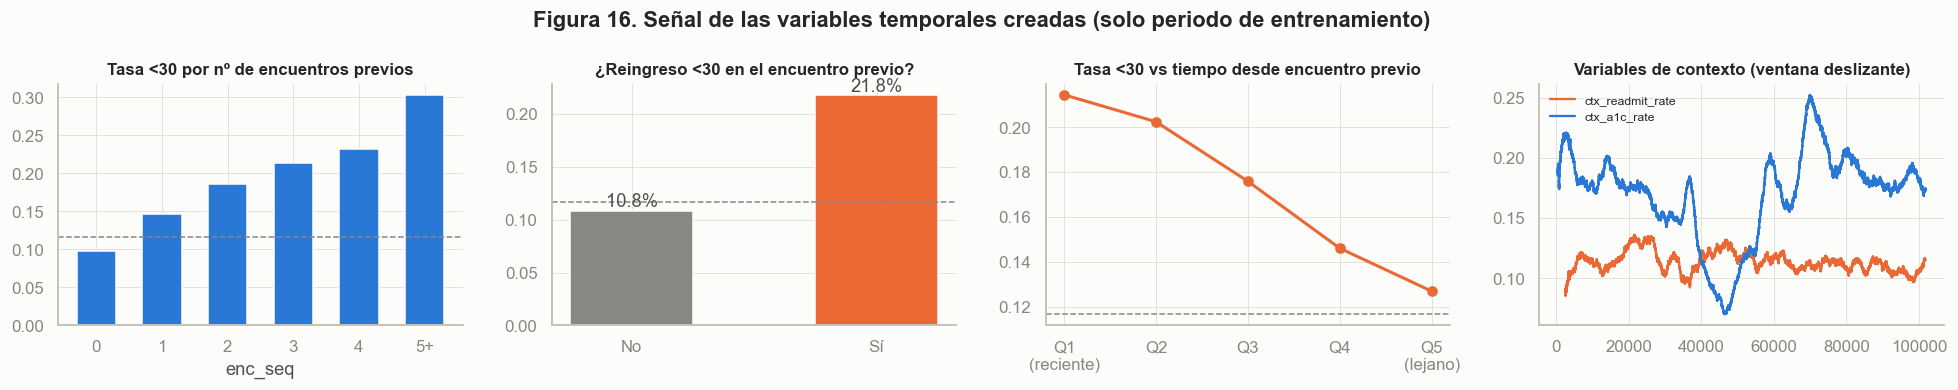

,AUC_univariado(|·|)
service_utilization,0.6051
enc_seq,0.5733
is_returning,0.5677
rel_number_diagnoses,0.5555
hist_n_readmit30,0.5515
hist_rate_readmit30,0.5498
rel_num_medications,0.5486
prev_readmit30,0.5378
log_gap_prev_encounter,0.5306
n_meds_changed,0.5253


In [30]:
FE_EVAL = data.period <= 11   # la exploración de nuevas variables usa solo el periodo de entrenamiento
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
d_ = data[FE_EVAL]
t1 = d_.groupby(d_.enc_seq.clip(upper=5))["target"].agg(["mean", "size"])
axes[0].bar([str(i) if i < 5 else "5+" for i in t1.index], t1["mean"], color=C1, width=0.6)
axes[0].set_title("Tasa <30 por nº de encuentros previos"); axes[0].set_xlabel("enc_seq")
t2 = d_.groupby("prev_readmit30")["target"].mean()
b = axes[1].bar(["No", "Sí"], t2.values, color=[MUTED, C2], width=0.5)
axes[1].bar_label(b, labels=[f"{v:.1%}" for v in t2.values], color=INK2)
axes[1].set_title("¿Reingreso <30 en el encuentro previo?")
t3 = d_[d_.is_returning == 1].groupby(pd.qcut(d_.loc[d_.is_returning == 1, "log_gap_prev_encounter"], 5))["target"].mean()
axes[2].plot(range(5), t3.values, color=C2, marker="o")
axes[2].set_xticks(range(5), ["Q1\n(reciente)", "Q2", "Q3", "Q4", "Q5\n(lejano)"])
axes[2].set_title("Tasa <30 vs tiempo desde encuentro previo")
axes[3].plot(data.t_idx, data.ctx_readmit_rate, color=C2, lw=1.5, label="ctx_readmit_rate")
axes[3].plot(data.t_idx, data.ctx_a1c_rate, color=C1, lw=1.5, label="ctx_a1c_rate")
axes[3].set_title("Variables de contexto (ventana deslizante)"); axes[3].legend(fontsize=8)
for ax in axes[:3]:
    ax.axhline(d_.target.mean(), color=MUTED, ls="--", lw=1)
fig.suptitle("Figura 16. Señal de las variables temporales creadas (solo periodo de entrenamiento)", fontweight="bold")
plt.tight_layout(); plt.show()

new_feats = ["service_utilization", "n_meds_active", "n_meds_changed", "meds_per_day", "n_comorbidity_groups",
             "dm_complicated", "a1c_tested"] + TEMPORAL_FEATS + CONTEXT_FEATS
fe_signal = pd.Series({c: roc_auc_score(d_.target, d_[c].fillna(d_[c].median())) for c in new_feats})
fe_signal = (fe_signal - 0.5).abs().add(0.5).sort_values(ascending=False).rename("AUC_univariado(|·|)")
fe_signal.to_frame().head(15)

## 9. División temporal de los datos

| Conjunto | Periodos | Uso |
|---|---|---|
| **Train** | 0–11 (60 %) | Ajuste de modelos y de todo el preprocesamiento |
| **Validación** | 12–15 (20 %) | Selección de hiperparámetros, umbral y calibración |
| **Test** | 16–19 (20 %) | Evaluación final, una sola vez, en el futuro "no visto" |

**Embargo:** se eliminan los últimos `LABEL_DELAY` encuentros de train y de validación, porque sus etiquetas (reingreso en los 30 días siguientes) aún no serían observables al momento del corte. 
**No se usa `shuffle` ni validación cruzada aleatoria**, que mezclaría futuro y pasado. (se realiza esto para evitar colocar accidentalemnte un paciente en trian y test)

,n,% del total,tasa <30,t_idx inicio,t_idx fin,% pacientes vistos en train
train,"57,709.0000",58.0924,0.1167,0.0000,"59,059.0000",100.0000
validación,"17,912.0000",18.0310,0.1110,"61,060.0000","79,412.0000",20.9915
test,"19,830.0000",19.9617,0.1087,"81,413.0000","101,765.0000",10.9481
embargo (descartado),"3,889.0000",3.9148,0.1119,"59,060.0000","81,412.0000",23.1936


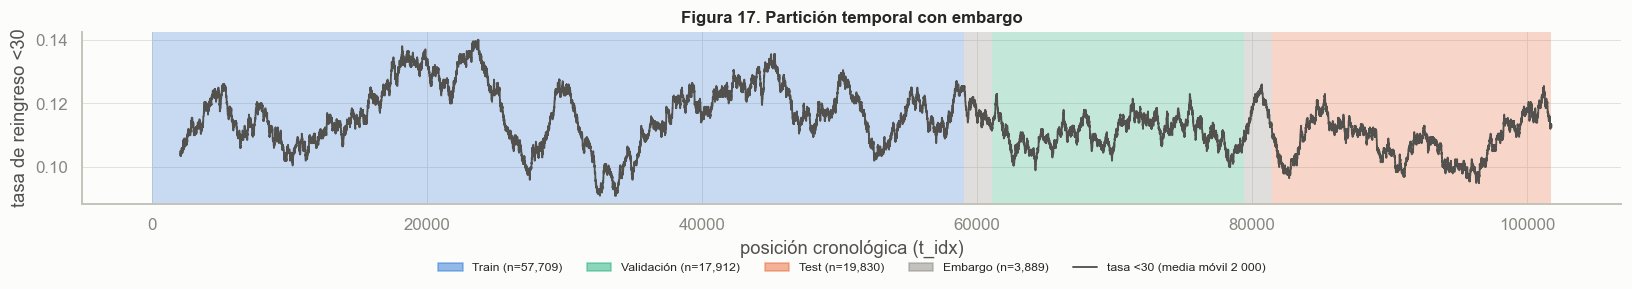

In [31]:
TRAIN_P, VAL_P, TEST_P = list(range(0, 12)), list(range(12, 16)), list(range(16, 20))
val_start = data.loc[data.period.isin(VAL_P), "t_idx"].min()
test_start = data.loc[data.period.isin(TEST_P), "t_idx"].min()

def split_masks(delay):
    m_tr = data.period.isin(TRAIN_P) & (data.t_idx < val_start - delay)
    m_va = data.period.isin(VAL_P) & (data.t_idx < test_start - delay)
    m_te = data.period.isin(TEST_P)
    return m_tr, m_va, m_te, ~(m_tr | m_va | m_te)

m_train, m_val, m_test, m_embargo = split_masks(LABEL_DELAY)

# Especialidades más frecuentes: se aprenden SOLO del train
TOP_SPEC = data.loc[m_train, "medical_specialty"].value_counts().head(15).index
data["specialty_grp"] = data.medical_specialty.where(data.medical_specialty.isin(TOP_SPEC), "Other")

train_pat = set(data.loc[m_train, "patient_nbr"])
split_tbl = pd.DataFrame({
    name: {"n": m.sum(), "% del total": m.mean() * 100, "tasa <30": data.loc[m, "target"].mean(),
           "t_idx inicio": data.loc[m, "t_idx"].min(), "t_idx fin": data.loc[m, "t_idx"].max(),
           "% pacientes vistos en train": data.loc[m, "patient_nbr"].isin(train_pat).mean() * 100}
    for name, m in [("train", m_train), ("validación", m_val), ("test", m_test), ("embargo (descartado)", m_embargo)]
}).T
display(split_tbl)
assert data.loc[m_train, "t_idx"].max() < data.loc[m_val, "t_idx"].min() < data.loc[m_test, "t_idx"].min()

fig, ax = plt.subplots(figsize=(15, 3))
seg = [(m_train, C1, "Train"), (m_val, C3, "Validación"), (m_test, C2, "Test"), (m_embargo, MUTED, "Embargo")]
handles = []
for m, c, lab in seg:
    idx = data.loc[m, "t_idx"].values
    # bloques contiguos de t_idx
    breaks = np.where(np.diff(idx) > LABEL_DELAY // 2)[0]
    for s, e in zip(np.r_[0, breaks + 1], np.r_[breaks, len(idx) - 1]):
        ax.axvspan(idx[s], idx[e], color=c, alpha=0.25, lw=0)
    handles.append(mpatches.Patch(color=c, alpha=0.5, label=f"{lab} (n={m.sum():,})"))
ax.plot(data.t_idx, data.target.rolling(2000).mean(), color=INK2, lw=1.2)
handles.append(plt.Line2D([], [], color=INK2, lw=1.2, label="tasa <30 (media móvil 2 000)"))
ax.set_ylabel("tasa de reingreso <30"); ax.set_xlabel("posición cronológica (t_idx)")
ax.legend(handles=handles, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.28), fontsize=8)
ax.set_title("Figura 17. Partición temporal con embargo")
plt.tight_layout(); plt.show()

Hemos optado por no usar la variable race debido a restricciones éticas

In [32]:
# `race` NO se usa como predictor (restricción ética: no usar raza para priorizar pacientes): se conserva solo para auditar equidad
CAT_FEATS = ["gender","admission_type_grp", "discharge_grp", "admission_source_grp", "specialty_grp",
             "diag_1_grp", "diag_2_grp", "diag_3_grp", "max_glu_serum", "A1Cresult", "insulin", "metformin",
             "glipizide", "glyburide", "pioglitazone", "rosiglitazone", "glimepiride", "change", "diabetesMed"]
STATIC_NUM = ["age_num", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
              "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses_capped",
              "service_utilization", "n_meds_active", "n_meds_changed", "meds_per_day", "labs_per_day",
              "n_comorbidity_groups", "dm_primary", "dm_complicated", "a1c_tested", "a1c_high", "glu_tested", "glu_high"]

NUM_FEATS = STATIC_NUM + TEMPORAL_FEATS
FEATURES = NUM_FEATS + CAT_FEATS
print(f"{len(FEATURES)} variables finales: {len(STATIC_NUM)} numéricas estáticas, {len(TEMPORAL_FEATS)} temporales por paciente, "
      f"{len(CAT_FEATS)} categóricas (+{len(CONTEXT_FEATS)} de contexto opcionales)")

X_train, y_train = data.loc[m_train, FEATURES], data.loc[m_train, "target"]
X_val, y_val = data.loc[m_val, FEATURES], data.loc[m_val, "target"]
X_test, y_test = data.loc[m_test, FEATURES], data.loc[m_test, "target"]

psi_split = pd.Series({c: (psi_categorical if c in CAT_FEATS else psi_numeric)(data.loc[m_train, c], data.loc[m_test, c])
                       for c in FEATURES + CONTEXT_FEATS})
psi_split.sort_values(ascending=False).head(10).rename("PSI train→test").to_frame()

54 variables finales: 21 numéricas estáticas, 14 temporales por paciente, 19 categóricas (+5 de contexto opcionales)


,PSI train→test
ctx_inpatient_mean,3.9235
ctx_a1c_rate,3.5690
rel_number_diagnoses,3.3625
ctx_readmit_rate,3.3119
specialty_grp,0.6631
log_gap_prev_encounter,0.4764
discharge_grp,0.3830
number_diagnoses_capped,0.3303
admission_source_grp,0.2843
prev_number_diagnoses_capped,0.2637


## 10. Detección de *data leakage*

Hay **fuga de información** cuando el modelo aprende de datos que **no existirán en el momento de predecir**. Da métricas excelentes en validación y luego falla en producción. En este proyecto el momento de predicción es **el alta hospitalaria** del encuentro actual. Por eso toda variable debe conocerse en ese instante, y el entrenamiento solo puede usar etiquetas que ya fueran observables en la fecha de corte.

Se auditan cinco tipos de fuga:

| Tipo | Pregunta | Prueba |
|---|---|---|
| Fuga de objetivo | ¿Alguna variable se genera después del alta o es un reflejo de `readmitted`? | 10.1 disponibilidad temporal · 10.2 cribado de señal |
| Fuga temporal (latencia de etiqueta) | ¿Se entrena con etiquetas que aún no se habrían observado? | 10.3 calibración del embargo |
| Contaminación entre conjuntos | ¿Train y test comparten filas o pacientes de forma que el modelo memorice? | 10.4 |
| Fuga en el pipeline | ¿El modelo encuentra señal donde no debería haberla? | 10.5 etiquetas permutadas, ablación, importancias |
| Fuga por decisiones del analista | ¿Alguna decisión de preprocesamiento se tomó mirando el test? | 10.6 |

### 10.1 Auditoría de disponibilidad temporal

In [33]:
AT_ADMISSION = ["age_num", "gender", "admission_type_grp", "admission_source_grp", "number_outpatient",
                "number_emergency", "number_inpatient", "service_utilization"]
LABEL_FEATS = ["prev_readmit30", "hist_n_readmit30", "hist_rate_readmit30"]   # usan la etiqueta de encuentros previos
ALL_FEATS = FEATURES + CONTEXT_FEATS
FORBIDDEN = {"readmitted", "target", "encounter_id", "patient_nbr", "t_idx", "period", "race"}

def availability(c):
    if c in LABEL_FEATS:
        return "Historial (etiquetas previas)", "Sí", "Etiqueta de encuentros anteriores: el reingreso ya ocurrió al volver el paciente"
    if c == "ctx_readmit_rate":
        return "Contexto (ventana pasada)", "Sí", f"Embargo de LABEL_DELAY = {LABEL_DELAY:,} encuentros"
    if c in TEMPORAL_FEATS:
        return "Historial (encuentros previos)", "No", "Solo shift / cumsum hacia atrás (prueba de truncamiento)"
    if c in CONTEXT_FEATS:
        return "Contexto (ventana pasada)", "No", "shift(1) antes de la ventana deslizante"
    if c in AT_ADMISSION:
        return "Ingreso", "No", "Conocida al admitir al paciente"
    return "Alta", "No", "Registrada durante la estancia o al alta"

avail = pd.DataFrame([availability(c) for c in ALL_FEATS], index=pd.Index(ALL_FEATS, name="variable"),
                     columns=["momento_disponible", "usa_etiqueta", "control_anti_fuga"])
print("Columnas prohibidas entre los predictores:", sorted(FORBIDDEN & set(ALL_FEATS)) or "ninguna")
display(avail.groupby(["momento_disponible", "usa_etiqueta"]).size().rename("n_variables").to_frame())
avail[avail.usa_etiqueta == "Sí"]

Columnas prohibidas entre los predictores: ninguna


n_variables
momento_disponible             usa_etiqueta             
Alta                           No                     32
Contexto (ventana pasada)      No                      4
                               Sí                      1
Historial (encuentros previos) No                     11
Historial (etiquetas previas)  Sí                      3
Ingreso                        No                      8

,momento_disponible,usa_etiqueta,control_anti_fuga
variable,,,
prev_readmit30,Historial (etiquetas previas),Sí,Etiqueta de encuentros anteriores: el reingres...
hist_n_readmit30,Historial (etiquetas previas),Sí,Etiqueta de encuentros anteriores: el reingres...
hist_rate_readmit30,Historial (etiquetas previas),Sí,Etiqueta de encuentros anteriores: el reingres...
ctx_readmit_rate,Contexto (ventana pasada),Sí,"Embargo de LABEL_DELAY = 2,000 encuentros"


**Resultado:**
- Ninguna variable se genera **después del alta**, y ni `readmitted`, ni los identificadores, ni el eje temporal (`t_idx`, `period`) ni `race` están entre los predictores.
- Las 4 variables que usan la etiqueta miran solo el **pasado**. Si el encuentro previo terminó en reingreso <30, ese reingreso ya ocurrió (muchas veces es el propio encuentro actual), así que es observable. `ctx_readmit_rate` usa etiquetas con embargo.
- ⚠️ Esto vale para una predicción **al alta**. Si el sistema se usara **al ingreso**, `discharge_grp`, `time_in_hospital`, los conteos de procedimientos, laboratorio y medicamentos, los diagnósticos y los cambios de medicación serían fuga y habría que excluirlos.

### 10.2 Cribado de variables "demasiado buenas" e identificadores
Una variable con fuga suele separar el objetivo casi por sí sola. Se calcula el AUC univariado de cada variable **en train**. En las categóricas se usa la tasa de reingreso por categoría, que es una cota superior de su señal. También se buscan categorías con separación perfecta y se comprueba que los identificadores no predicen el objetivo.

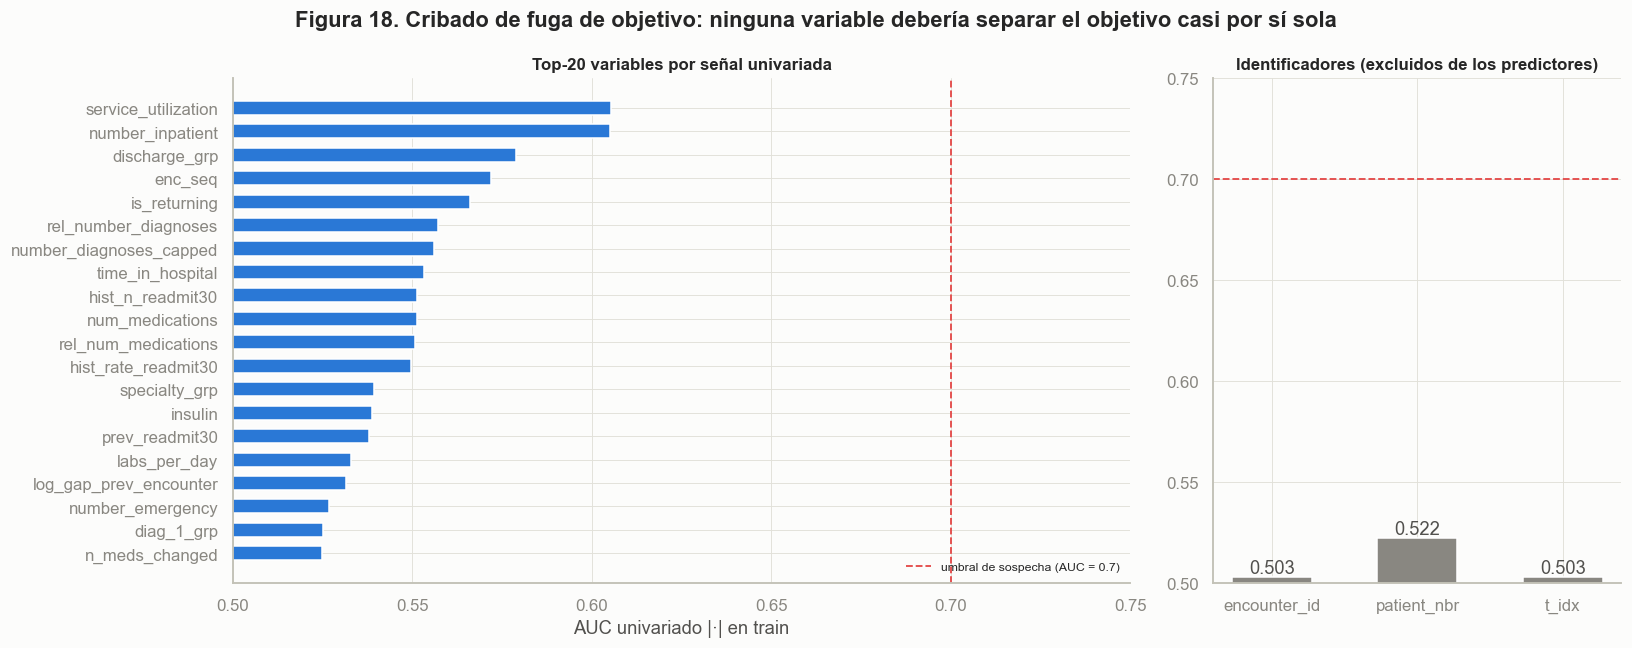

Variables con AUC univariado > 0.7: ninguna
Categorías (n ≥ 30) con separación perfecta del objetivo: ninguna


In [34]:
d_tr = data[m_train]

def auc_sym(y, x):
    a = roc_auc_score(y, x)
    return max(a, 1 - a)

LEAK_AUC = 0.70   # ninguna variable aislada debería acercarse al desempeño de un modelo completo
id_auc = pd.Series({c: auc_sym(d_tr.target, d_tr[c]) for c in ["encounter_id", "patient_nbr", "t_idx"]})
screen = pd.Series({c: auc_sym(d_tr.target, d_tr[c].fillna(d_tr[c].median())) for c in NUM_FEATS + CONTEXT_FEATS})
for c in CAT_FEATS:
    screen[c] = auc_sym(d_tr.target, d_tr.groupby(c)["target"].transform("mean"))
screen = screen.sort_values(ascending=False)
cat_rates = [(c, k, int(r["size"])) for c in CAT_FEATS
             for k, r in d_tr.groupby(c)["target"].agg(["mean", "size"]).iterrows()
             if r["size"] >= 30 and r["mean"] in (0, 1)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2.2, 1]})
top = screen.head(20)[::-1]
axes[0].barh(top.index, top.values, color=[C8 if v > LEAK_AUC else C1 for v in top.values], height=0.6)
axes[0].axvline(LEAK_AUC, color=C8, ls="--", lw=1.2, label=f"umbral de sospecha (AUC = {LEAK_AUC})")
axes[0].set_xlim(0.5, max(LEAK_AUC + 0.05, top.max() + 0.02)); axes[0].set_xlabel("AUC univariado |·| en train")
axes[0].set_title("Top-20 variables por señal univariada"); axes[0].legend(fontsize=8, loc="lower right")
b = axes[1].bar(id_auc.index, id_auc.values, color=MUTED, width=0.55)
axes[1].bar_label(b, fmt="%.3f", color=INK2)
axes[1].axhline(LEAK_AUC, color=C8, ls="--", lw=1.2); axes[1].set_ylim(0.5, LEAK_AUC + 0.05)
axes[1].set_title("Identificadores (excluidos de los predictores)")
fig.suptitle("Figura 18. Cribado de fuga de objetivo: ninguna variable debería separar el objetivo casi por sí sola",
             fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Variables con AUC univariado > {LEAK_AUC}: {list(screen[screen > LEAK_AUC].index) or 'ninguna'}")
print(f"Categorías (n ≥ 30) con separación perfecta del objetivo: {cat_rates or 'ninguna'}")

**Resultado:** las variables más informativas (`number_inpatient` y `service_utilization`) llegan a un AUC univariado de apenas ≈ 0.61, y ninguna categoría separa el objetivo por completo. Los identificadores tienen AUC ≈ 0.50–0.52: `patient_nbr` también crece con el tiempo y arrastra el pequeño *prior shift*, pero no es un predictor. **No hay indicios de fuga de objetivo.**

### 10.3 Latencia de etiqueta: calibración empírica del embargo
La etiqueta de un encuentro solo se conoce cuando el paciente reingresa (o cuando pasan 30 días sin que lo haga). El dataset no tiene fechas, pero la latencia puede **medirse**. Para cada encuentro seguido de otro del mismo paciente, si la distancia `Δ t_idx` equivale a menos de 30 días, el encuentro está etiquetado `<30` casi siempre. La distancia a la que $P(\text{target}=1 \mid \Delta)$ se desploma es el **equivalente empírico de 30 días**, medido en encuentros.

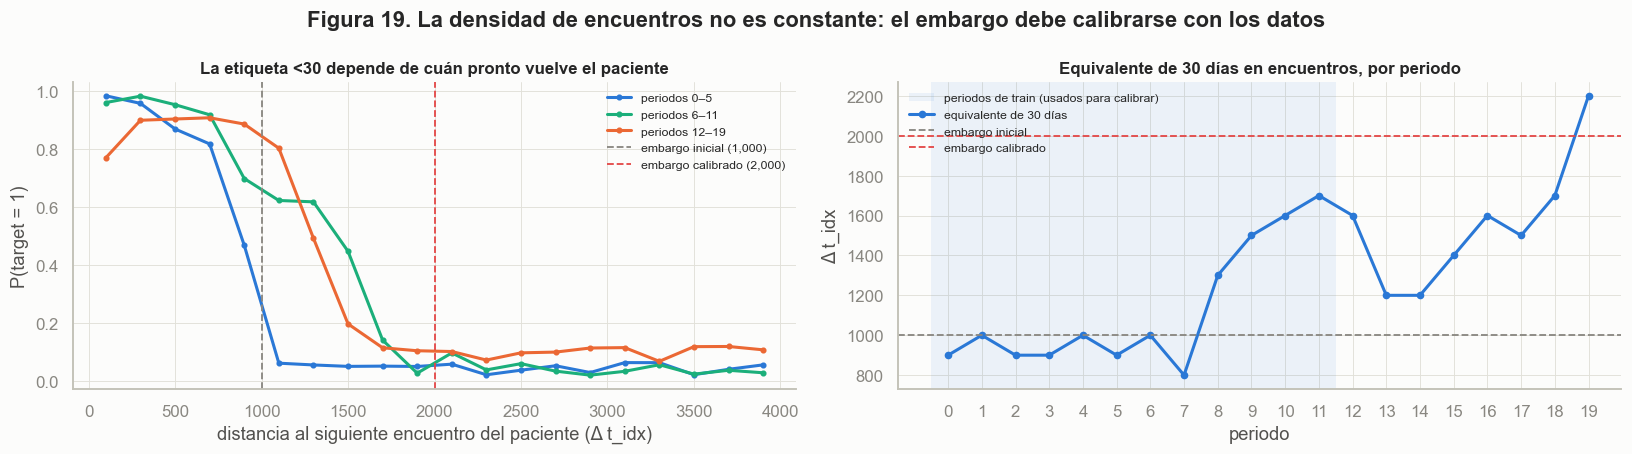

,inicial,calibrado
embargo (encuentros),"1,000.0000","2,000.0000"
train: positivos cuyo siguiente encuentro cae después del corte,111.0000,93.0000
"train: … de ellos, reingreso <30 real dentro del dataset (fuga)",11.0000,0.0000
validación: positivos cuyo siguiente encuentro cae en test,53.0000,39.0000
"validación: … de ellos, reingreso <30 real dentro del dataset (fuga)",5.0000,0.0000
% de positivos con Δ ≤ embargo,72.9000,86.9000
encuentros descartados por embargo,"1,943.0000","3,889.0000"


In [35]:
gap_next = next_gap(data)
next_t = data.t_idx + gap_next
bound_all = pd.Series({p: readmission_boundary(gap_next[data.period == p], data.target[data.period == p])
                       for p in range(N_PERIODS)})

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
bins = np.arange(0, 4001, 200)
for (name, ps), c in zip({"periodos 0–5": range(0, 6), "periodos 6–11": range(6, 12),
                          "periodos 12–19": range(12, 20)}.items(), [C1, C3, C2]):
    msk = data.period.isin(ps) & gap_next.notna()
    r = data.loc[msk, "target"].groupby(pd.cut(gap_next[msk], bins), observed=False).mean()
    axes[0].plot(bins[:-1] + 100, r.values, color=c, marker="o", ms=3, label=name)
axes[0].axvline(LABEL_DELAY_NAIVE, color=MUTED, ls="--", lw=1.2, label=f"embargo inicial ({LABEL_DELAY_NAIVE:,})")
axes[0].axvline(LABEL_DELAY, color=C8, ls="--", lw=1.2, label=f"embargo calibrado ({LABEL_DELAY:,})")
axes[0].set_xlabel("distancia al siguiente encuentro del paciente (Δ t_idx)"); axes[0].set_ylabel("P(target = 1)")
axes[0].set_title("La etiqueta <30 depende de cuán pronto vuelve el paciente"); axes[0].legend(fontsize=8)

axes[1].axvspan(-0.5, 11.5, color=C1, alpha=0.08, lw=0, label="periodos de train (usados para calibrar)")
axes[1].plot(bound_all.index, bound_all.values, color=C1, marker="o", ms=4, label="equivalente de 30 días")
axes[1].axhline(LABEL_DELAY_NAIVE, color=MUTED, ls="--", lw=1.2, label="embargo inicial")
axes[1].axhline(LABEL_DELAY, color=C8, ls="--", lw=1.2, label="embargo calibrado")
axes[1].set_xticks(range(N_PERIODS)); axes[1].set_xlabel("periodo"); axes[1].set_ylabel("Δ t_idx")
axes[1].set_title("Equivalente de 30 días en encuentros, por periodo"); axes[1].legend(fontsize=8, loc="upper left")
fig.suptitle("Figura 19. La densidad de encuentros no es constante: el embargo debe calibrarse con los datos",
             fontweight="bold")
plt.tight_layout(); plt.show()

# Reingreso "observable en el dataset": el siguiente encuentro cae dentro del equivalente de 30 días de su periodo
readmit_in_data = data.target.eq(1) & (gap_next <= data.period.map(bound_all))

def latency_leak(delay):
    mt, mv, _, me = split_masks(delay)
    pos_next = data.target.eq(1) & gap_next.notna()
    return {"embargo (encuentros)": delay,
            "train: positivos cuyo siguiente encuentro cae después del corte": int((mt & pos_next & (next_t >= val_start)).sum()),
            "train: … de ellos, reingreso <30 real dentro del dataset (fuga)": int((mt & readmit_in_data & (next_t >= val_start)).sum()),
            "validación: positivos cuyo siguiente encuentro cae en test": int((mv & pos_next & (next_t >= test_start)).sum()),
            "validación: … de ellos, reingreso <30 real dentro del dataset (fuga)": int((mv & readmit_in_data & (next_t >= test_start)).sum()),
            "% de positivos con Δ ≤ embargo": round(100 * (gap_next[pos_next] <= delay).mean(), 1),
            "encuentros descartados por embargo": int(me.sum())}

latency_tbl = pd.DataFrame({"inicial": latency_leak(LABEL_DELAY_NAIVE), "calibrado": latency_leak(LABEL_DELAY)})
latency_tbl

**Resultado (fuga detectada y corregida):**
- Al principio del periodo de estudio, 30 días equivalen a ≈ 900 encuentros. En los periodos 9–11, justo antes del corte train/validación, equivalen a ≈ 1 500–1 700. **La hipótesis de densidad constante no se cumple.**
- Con el embargo inicial de 1 000 encuentros, hay positivos de train y de validación cuyo reingreso **real y presente en el dataset** (siguiente encuentro dentro del equivalente de 30 días) ocurre **después** del corte. Esas etiquetas no se habrían conocido en la fecha de entrenamiento, así que era una **fuga temporal**. La misma subestimación afectaba a `ctx_readmit_rate`, que se calculaba con etiquetas aún no observables.
- **Corrección aplicada:** `LABEL_DELAY` se calibra en la Sección 8 solo con los periodos de train (el máximo por periodo, redondeado a 500) y se usa en el embargo del split y en `ctx_readmit_rate`. Con el embargo calibrado, esa fuga baja a **0**. Los positivos que siguen "cruzando" el corte tienen su siguiente encuentro muy lejos: su reingreso real fue a un encuentro **que no está en el dataset** (no diabético o de otro hospital) y ningún embargo lo puede capturar.
- ⚠️ **Para el modelado:** `03_modelado.ipynb` usa `EMBARGO = 850`, por debajo de la latencia medida. Debe alinearse con `label_delay_encuentros` de `metadata_preparacion.json`.

### 10.4 Contaminación entre conjuntos

In [36]:
def row_hash(X):
    return pd.util.hash_pandas_object(X.astype(str), index=False)

h_train = set(row_hash(X_train))
seen_test = data.loc[m_test, "patient_nbr"].isin(train_pat).values
contamination = pd.Series({
    "encounter_id compartidos entre conjuntos": len(set(data.loc[m_train, "encounter_id"])
                                                   & set(data.loc[m_val | m_test, "encounter_id"])),
    "filas de validación idénticas a una de train": int(row_hash(X_val).isin(h_train).sum()),
    "filas de test idénticas a una de train": int(row_hash(X_test).isin(h_train).sum()),
    "separación train → validación (encuentros)": int(data.loc[m_val, "t_idx"].min() - data.loc[m_train, "t_idx"].max()),
    "separación validación → test (encuentros)": int(data.loc[m_test, "t_idx"].min() - data.loc[m_val, "t_idx"].max()),
    "% encuentros de test de pacientes vistos en train": round(100 * seen_test.mean(), 1),
}, name="valor")
contamination.to_frame()

,valor
encounter_id compartidos entre conjuntos,0.0000
filas de validación idénticas a una de train,0.0000
filas de test idénticas a una de train,0.0000
separación train → validación (encuentros),"2,001.0000"
separación validación → test (encuentros),"2,001.0000"
% encuentros de test de pacientes vistos en train,10.9000


**Resultado:** no hay encuentros duplicados ni vectores de variables idénticos entre conjuntos, y los conjuntos están separados al menos por el embargo. Que un paciente aparezca en train y en test **no es fuga**: en producción los pacientes vuelven, y el modelo no usa `patient_nbr`, solo su historial pasado. Aun así se verifica en 10.5 que el modelo no rinde mejor con los pacientes "conocidos", lo que delataría memorización.

### 10.5 Pruebas con modelo: etiquetas permutadas, ablación e importancias
- **Etiquetas permutadas:** entrenado con `y` barajada, el modelo debe dar AUC ≈ 0.5 en validación. Si da más, el pipeline filtra el objetivo por otra vía.
- **Ablación por familias:** cuánto aporta cada familia de variables. Un salto enorme al añadir una familia sería sospechoso.
- **Importancia por permutación en validación:** ninguna variable debería concentrar la mayor parte de la señal.
- **Pacientes vistos vs nuevos en test:** un desempeño similar descarta la memorización.

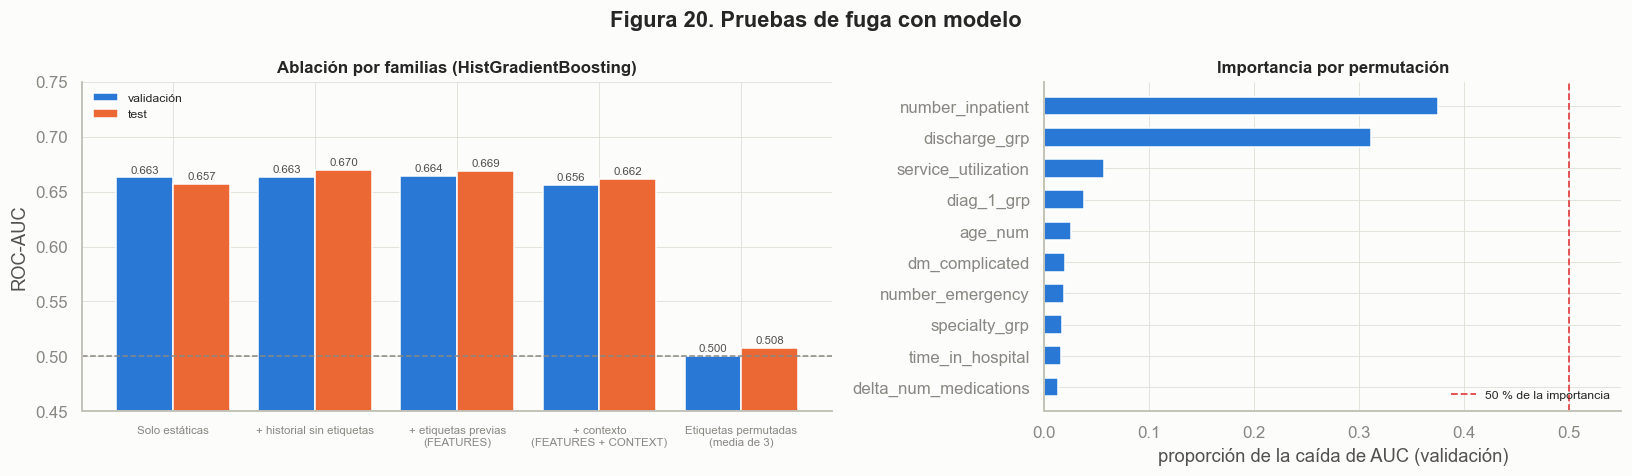

AUC en test, pacientes vistos en train: 0.650 | pacientes nuevos: 0.662


,train,val,test,brecha train − val
Solo estáticas,0.7460,0.6630,0.6570,0.0830
+ historial sin etiquetas,0.7460,0.6630,0.6700,0.0830
+ etiquetas previas (FEATURES),0.7430,0.6640,0.6690,0.0790
+ contexto (FEATURES + CONTEXT),0.7740,0.6560,0.6620,0.1170
Etiquetas permutadas (media de 3),0.4960,0.5000,0.5080,-0.0040


In [37]:
def prep(m):
    X = data.loc[m, ALL_FEATS].copy()
    for c in CAT_FEATS:
        X[c] = pd.Categorical(X[c].astype(str), categories=sorted(data.loc[m_train, c].astype(str).unique()))
    return X

XA = {"train": prep(m_train), "val": prep(m_val), "test": prep(m_test)}
YA = {"train": y_train, "val": y_val, "test": y_test}

def fit_eval(cols, y_fit=None):
    mdl = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, categorical_features="from_dtype",
                                         random_state=SEED)
    mdl.fit(XA["train"][cols], YA["train"] if y_fit is None else y_fit)
    return mdl, {k: roc_auc_score(YA[k], mdl.predict_proba(XA[k][cols])[:, 1]) for k in XA}

variants = {
    "Solo estáticas": STATIC_NUM + CAT_FEATS,
    "+ historial sin etiquetas": STATIC_NUM + CAT_FEATS + [c for c in TEMPORAL_FEATS if c not in LABEL_FEATS],
    "+ etiquetas previas (FEATURES)": FEATURES,
    "+ contexto (FEATURES + CONTEXT)": ALL_FEATS,
}
abl = {}
for name, cols in variants.items():
    mdl, abl[name] = fit_eval(cols)
    if name == "+ etiquetas previas (FEATURES)":
        base_model = mdl
perm_runs = pd.DataFrame([fit_eval(FEATURES, rng.permutation(y_train.values))[1] for _ in range(3)])
abl["Etiquetas permutadas (media de 3)"] = perm_runs.mean().to_dict()
abl = pd.DataFrame(abl).T
abl["brecha train − val"] = abl.train - abl.val

p_test = base_model.predict_proba(XA["test"][FEATURES])[:, 1]
auc_seen = roc_auc_score(y_test[seen_test], p_test[seen_test])
auc_new = roc_auc_score(y_test[~seen_test], p_test[~seen_test])

pi_val = permutation_importance(base_model, XA["val"][FEATURES], y_val, scoring="roc_auc",
                                n_repeats=3, random_state=SEED)
imp_share = pd.Series(pi_val.importances_mean, index=FEATURES).clip(lower=0)
imp_share = (imp_share / imp_share.sum()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
x = np.arange(len(abl))
axes[0].bar(x - 0.2, abl.val, width=0.4, color=C1, label="validación")
axes[0].bar(x + 0.2, abl.test, width=0.4, color=C2, label="test")
for xi, (v, t) in enumerate(zip(abl.val, abl.test)):
    axes[0].text(xi - 0.2, v + 0.004, f"{v:.3f}", ha="center", fontsize=7.5, color=INK2)
    axes[0].text(xi + 0.2, t + 0.004, f"{t:.3f}", ha="center", fontsize=7.5, color=INK2)
axes[0].axhline(0.5, color=MUTED, ls="--", lw=1)
axes[0].set_xticks(x, [n.replace(" (", "\n(") for n in abl.index], fontsize=7.5)
axes[0].set_ylim(0.45, max(0.75, abl[["val", "test"]].max().max() + 0.03)); axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("Ablación por familias (HistGradientBoosting)"); axes[0].legend(fontsize=8, loc="upper left")
top_imp = imp_share.head(10)[::-1]
axes[1].barh(top_imp.index, top_imp.values, color=C1, height=0.6)
axes[1].axvline(0.5, color=C8, ls="--", lw=1.2, label="50 % de la importancia")
axes[1].set_xlim(0, max(0.55, top_imp.max() + 0.05)); axes[1].legend(fontsize=8, loc="lower right")
axes[1].set_xlabel("proporción de la caída de AUC (validación)"); axes[1].set_title("Importancia por permutación")
fig.suptitle("Figura 20. Pruebas de fuga con modelo", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"AUC en test, pacientes vistos en train: {auc_seen:.3f} | pacientes nuevos: {auc_new:.3f}")
abl.round(3)

**Resultado:**
- Con etiquetas permutadas el AUC cae a ≈ 0.5: **el pipeline no filtra el objetivo por ninguna vía indirecta.**
- El modelo completo logra un AUC en validación/test ≈ 0.66–0.67, coherente con la dificultad del problema (ninguna señal individual pasa de 0.61). Un AUC > 0.80 sería la señal de alarma típica de una fuga.
- El historial por paciente y las etiquetas previas aportan una mejora **pequeña pero consistente** en test (≈ +0.01 AUC sobre las estáticas), sin saltos sospechosos. Es un **enriquecimiento legítimo**.
- ⚠️ **Las variables de contexto (`ctx_*`, `rel_*`) empeoran validación y test y aumentan la brecha train − validación.** No filtran la etiqueta, pero cambian por construcción con el tiempo (Sección 5): funcionan como un **proxy del periodo**, parecido a usar `t_idx`, y el modelo aprende particularidades de la época de entrenamiento que no se transfieren. **Recomendación: no usarlas** en el modelo base.
- Las dos variables más importantes, `number_inpatient` (≈ 38 %, hospitalizaciones en el año previo) y `discharge_grp` (≈ 31 %, destino al alta), son clínicamente esperables, y ninguna concentra la mayoría de la señal.
- El desempeño con pacientes nuevos es igual o mejor que con pacientes vistos en train, así que **no hay memorización de pacientes**.
- La brecha train − validación (≈ 0.08) se explica por el sobreajuste propio del boosting y por el *drift* (Sección 5), no por fuga: el desempeño en test es igual al de validación.

### 10.6 Fuga por decisiones del analista
El EDA de las Secciones 4–5 recorre los 20 periodos, y eso es aceptable como análisis descriptivo. Pero **toda decisión que modifica el dataset** debe poder justificarse **solo con train**. De lo contrario, el diseño del pipeline habría "visto" el test.

In [38]:
tr_raw = df[df.period.isin(TRAIN_P)]
psi_payer_train = psi_categorical(tr_raw.payer_code[tr_raw.period.isin(range(0, 4))],
                                  tr_raw.payer_code[tr_raw.period.isin(range(8, 12))])
analyst = pd.DataFrame([
    ("Recortar number_diagnoses a 9", f"máximo en train = {d_tr.number_diagnoses.max()}",
     d_tr.number_diagnoses.max() <= 9),
    ("Eliminar payer_code por drift", f"PSI periodos 0–3 vs 8–11 (solo train) = {psi_payer_train:.2f}",
     psi_payer_train > 0.25),
    ("Top-15 de medical_specialty", "value_counts sobre m_train",
     set(TOP_SPEC) == set(d_tr.medical_specialty.value_counts().head(15).index)),
    ("Isolation Forest de anomalías", "ajustado en periodos 0–3 (⊂ train); la puntuación no es predictor",
     not {"anomaly_score", "is_anomaly"} & set(ALL_FEATS)),
    ("Calibración de LABEL_DELAY", f"máximo por periodo 0–11 = {delay_by_period.max():,.0f} → {LABEL_DELAY:,}",
     True),
], columns=["decisión", "evidencia usando solo train", "reproducible_sin_test"])
analyst

,decisión,evidencia usando solo train,reproducible_sin_test
0,Recortar number_diagnoses a 9,máximo en train = 9,True
1,Eliminar payer_code por drift,PSI periodos 0–3 vs 8–11 (solo train) = 5.91,True
2,Top-15 de medical_specialty,value_counts sobre m_train,True
3,Isolation Forest de anomalías,ajustado en periodos 0–3 (⊂ train); la puntuac...,True
4,Calibración de LABEL_DELAY,"máximo por periodo 0–11 = 1,700 → 2,000",True


**Resultado:** todas las decisiones pueden reproducirse sin mirar validación ni test. El recorte de `number_diagnoses` en 9 es el máximo observado en train, así que el régimen de >9 diagnósticos que aparece en el periodo 17 queda fuera del dominio de entrenamiento. El *drift* de `payer_code` ya es > 0.25 dentro de train.

### 10.7 Resumen de la auditoría de fuga

In [39]:
lat = latency_tbl.iloc[2].astype(int)   # train: reingresos reales que cruzan el corte
leak_summary = pd.DataFrame([
    ("Disponibilidad al alta", "ninguna variable posterior al alta; columnas prohibidas ausentes",
     "OK" if not FORBIDDEN & set(ALL_FEATS) else "Revisar"),
    ("Cribado univariado", f"AUC máx. = {screen.max():.3f} ({screen.idxmax()})",
     "OK" if screen.max() < LEAK_AUC else "Revisar"),
    ("Identificadores", f"AUC máx. = {id_auc.max():.3f}; excluidos de los predictores", "OK"),
    ("Separación perfecta en categorías", f"{len(cat_rates)} categorías", "OK" if not cat_rates else "Revisar"),
    ("Latencia de etiqueta", f"embargo {LABEL_DELAY_NAIVE:,} → {LABEL_DELAY:,}; reingresos de train que cruzan "
                             f"el corte {lat['inicial']} → {lat['calibrado']}",
     "Corregido" if lat["calibrado"] < lat["inicial"] else "OK"),
    ("Variables rezagadas sin futuro", "prueba de truncamiento (Sección 8)", "OK" if ok else "Revisar"),
    ("Filas idénticas entre conjuntos", f"val: {contamination.iloc[1]:.0f} · test: {contamination.iloc[2]:.0f}",
     "OK" if contamination.iloc[1] + contamination.iloc[2] == 0 else "Revisar"),
    ("Etiquetas permutadas", f"AUC val = {abl.loc['Etiquetas permutadas (media de 3)', 'val']:.3f}",
     "OK" if abs(abl.loc["Etiquetas permutadas (media de 3)", "val"] - 0.5) < 0.03 else "Revisar"),
    ("Desempeño plausible", f"AUC val = {abl.loc['+ etiquetas previas (FEATURES)', 'val']:.3f} · "
                            f"test = {abl.loc['+ etiquetas previas (FEATURES)', 'test']:.3f}",
     "OK" if abl.loc["+ etiquetas previas (FEATURES)", "val"] < 0.80 else "Revisar"),
    ("Pacientes vistos vs nuevos", f"AUC test {auc_seen:.3f} vs {auc_new:.3f}",
     "OK" if auc_seen - auc_new < 0.03 else "Revisar"),
    ("Variables de contexto (proxy del tiempo)",
     f"AUC val {abl.loc['+ etiquetas previas (FEATURES)', 'val']:.3f} → {abl.loc['+ contexto (FEATURES + CONTEXT)', 'val']:.3f}; "
     f"brecha train−val {abl.loc['+ etiquetas previas (FEATURES)', 'brecha train − val']:.3f} → "
     f"{abl.loc['+ contexto (FEATURES + CONTEXT)', 'brecha train − val']:.3f}",
     "No usar" if abl.loc["+ contexto (FEATURES + CONTEXT)", "val"] < abl.loc["+ etiquetas previas (FEATURES)", "val"] else "OK"),
    ("Dominancia de una variable", f"{imp_share.index[0]} = {imp_share.iloc[0]:.0%} de la importancia",
     "OK" if imp_share.iloc[0] < 0.5 else "Revisar"),
    ("Decisiones del analista", "todas reproducibles solo con train",
     "OK" if analyst.reproducible_sin_test.all() else "Revisar"),
], columns=["prueba", "resultado", "estado"])
leak_summary

,prueba,resultado,estado
0,Disponibilidad al alta,ninguna variable posterior al alta; columnas p...,OK
1,Cribado univariado,AUC máx. = 0.605 (service_utilization),OK
2,Identificadores,AUC máx. = 0.522; excluidos de los predictores,OK
3,Separación perfecta en categorías,0 categorías,OK
4,Latencia de etiqueta,"embargo 1,000 → 2,000; reingresos de train que...",Corregido
5,Variables rezagadas sin futuro,prueba de truncamiento (Sección 8),OK
6,Filas idénticas entre conjuntos,val: 0 · test: 0,OK
7,Etiquetas permutadas,AUC val = 0.500,OK
8,Desempeño plausible,AUC val = 0.664 · test = 0.669,OK
9,Pacientes vistos vs nuevos,AUC test 0.650 vs 0.662,OK


**Conclusiones para el modelado**
1. **No hay fuga de objetivo ni contaminación entre conjuntos.** Las métricas de validación y test son creíbles y comparables con lo que el sistema lograría en producción, prediciendo al alta.
2. **Se detectó y corrigió una fuga temporal:** el embargo por latencia de etiqueta de 1 000 encuentros era insuficiente en la segunda mitad del periodo de estudio. Ahora se calibra con los datos de train y se exporta en `metadata_preparacion.json` (`label_delay_encuentros`).
3. **Las variables de historial por paciente son un enriquecimiento legítimo:** aportan una mejora consistente sin saltos sospechosos, no dependen de haber visto al paciente en train y la prueba de truncamiento garantiza que solo usan el pasado.
4. **Las variables de contexto son un atajo temporal:** empeoran la generalización porque codifican el periodo. Se siguen exportando por trazabilidad, pero se recomienda excluirlas.
5. **Recomendaciones para `03_modelado.ipynb`:**
   - Usar como `EMBARGO` el `label_delay_encuentros` del metadata, en lugar de 850, en todo esquema de bloques, ventanas deslizantes y reentrenamiento.
   - Poner `USAR_CONTEXTO = False`.
   - En producción, calcular `prev_readmit30` / `hist_*` solo con etiquetas **ya confirmadas**. La etiqueta de un encuentro se cierra al reingresar el paciente o al pasar 30 días.
   - Cualquier variable nueva (p. ej. *target encoding*, tasas por hospital o por especialidad) debe calcularse **solo con el pasado y con el mismo embargo**, y volver a pasar las pruebas de esta sección, en particular la de etiquetas permutadas y el cribado univariado.
   - No usar la versión "al ingreso" del modelo con variables del alta (Sección 10.1).

## 11. Dataset final preparado y resumen del análisis

### 11.1 Diccionario de variables

In [40]:
FEATURE_DESC = {
    "age_num": "Punto medio del rango de edad",
    "number_diagnoses_capped": "Nº de diagnósticos recortado a 9 (armoniza cambio de codificación)",
    "service_utilization": "Visitas ambulatorias + emergencia + hospitalizaciones del año previo",
    "n_meds_active": "Nº de antidiabéticos activos en el encuentro",
    "n_meds_changed": "Nº de antidiabéticos con dosis aumentada o reducida",
    "meds_per_day": "Medicamentos por día de hospitalización",
    "labs_per_day": "Pruebas de laboratorio por día de hospitalización",
    "n_comorbidity_groups": "Nº de grupos clínicos ICD-9 distintos entre los 3 diagnósticos",
    "dm_primary": "Diabetes como diagnóstico principal",
    "dm_complicated": "Diabetes con complicaciones (ICD-9 250.1x–250.9x)",
    "a1c_tested": "HbA1c medida", "a1c_high": "HbA1c > 7 %",
    "glu_tested": "Glucosa sérica medida", "glu_high": "Glucosa sérica > 200",
    "enc_seq": "Nº de encuentros previos del paciente (lag)",
    "is_returning": "El paciente tiene al menos un encuentro previo",
    "prev_readmit30": "El encuentro previo terminó en reingreso <30 (lag de la etiqueta, observable)",
    "hist_n_readmit30": "Suma acumulada de reingresos <30 previos del paciente",
    "hist_rate_readmit30": "Proporción histórica de reingresos <30 del paciente",
    "prev_time_in_hospital": "Días de hospitalización del encuentro previo (lag 1)",
    "prev_num_medications": "Nº de medicamentos del encuentro previo (lag 1)",
    "prev_number_diagnoses_capped": "Nº de diagnósticos del encuentro previo (lag 1)",
    "prev_n_meds_active": "Antidiabéticos activos en el encuentro previo (lag 1)",
    "delta_num_medications": "Cambio en nº de medicamentos vs encuentro previo",
    "delta_n_meds_active": "Cambio en antidiabéticos activos vs encuentro previo",
    "roll3_time_in_hospital": "Media de días hospitalizado en los últimos 3 encuentros previos (ventana por paciente)",
    "log_gap_prev_encounter": "log(distancia en pseudo-tiempo desde el encuentro previo)",
    "prev_discharge_snf": "El encuentro previo fue alta a SNF / cuidados largos",
    "ctx_readmit_rate": f"Tasa de reingreso <30 en ventana de {CTX_W:,} encuentros, con embargo de {LABEL_DELAY:,}",
    "ctx_inpatient_mean": "Media de number_inpatient en la ventana reciente de 3 000 encuentros",
    "ctx_a1c_rate": "Proporción de HbA1c medida en la ventana reciente",
    "rel_number_diagnoses": "number_diagnoses menos la media de la ventana reciente (relativo al régimen vigente)",
    "rel_num_medications": "num_medications menos la media de la ventana reciente",
    "admission_type_grp": "Tipo de admisión agrupado", "discharge_grp": "Destino al alta agrupado",
    "admission_source_grp": "Fuente de admisión agrupada", "specialty_grp": "Especialidad (top-15 del train + Other)",
    "diag_1_grp": "Grupo ICD-9 del diagnóstico principal", "diag_2_grp": "Grupo ICD-9 del diagnóstico secundario",
    "diag_3_grp": "Grupo ICD-9 del diagnóstico adicional",
}

def family(c):
    if c in TEMPORAL_FEATS: return "Temporal por paciente (lag / ventana)"
    if c in CONTEXT_FEATS: return "Contexto (ventana deslizante global) — opcional"
    if c in CAT_FEATS: return "Categórica"
    if c in NUM_RAW or c in ["age_num"]: return "Numérica original"
    return "Numérica derivada"

feat_dict = pd.DataFrame({
    "familia": [family(c) for c in FEATURES + CONTEXT_FEATS],
    "tipo": ["categórica" if c in CAT_FEATS else "numérica" for c in FEATURES + CONTEXT_FEATS],
    "%_faltante_train": [data.loc[m_train, c].isna().mean() * 100 for c in FEATURES + CONTEXT_FEATS],
    "PSI_train→test": [psi_split[c] for c in FEATURES + CONTEXT_FEATS],
    "descripción": [FEATURE_DESC.get(c, "Variable original del dataset") for c in FEATURES + CONTEXT_FEATS],
}, index=pd.Index(FEATURES + CONTEXT_FEATS, name="variable"))
display(feat_dict.groupby("familia").size().rename("n_variables").to_frame())
feat_dict

,n_variables
familia,
Categórica,19
Contexto (ventana deslizante global) — opcional,5
Numérica derivada,13
Numérica original,8
Temporal por paciente (lag / ventana),14


,familia,tipo,%_faltante_train,PSI_train→test,descripción
variable,,,,,
age_num,Numérica original,numérica,0.0000,0.0188,Punto medio del rango de edad
time_in_hospital,Numérica original,numérica,0.0000,0.0224,Variable original del dataset
num_lab_procedures,Numérica original,numérica,0.0000,0.0530,Variable original del dataset
num_procedures,Numérica original,numérica,0.0000,0.0078,Variable original del dataset
num_medications,Numérica original,numérica,0.0000,0.0411,Variable original del dataset
number_outpatient,Numérica original,numérica,0.0000,0.0550,Variable original del dataset
number_emergency,Numérica original,numérica,0.0000,0.0000,Variable original del dataset
number_inpatient,Numérica original,numérica,0.0000,0.0029,Variable original del dataset
number_diagnoses_capped,Numérica derivada,numérica,0.0000,0.3303,Nº de diagnósticos recortado a 9 (armoniza cam...


### 11.2 Exportación del dataset preparado
Se exportan los tres conjuntos con identificadores, eje temporal, variables finales, variables de contexto opcionales y objetivo, junto con un archivo de metadatos que documenta todas las decisiones (para que la etapa de modelado use exactamente la misma preparación).

In [41]:
OUT_DIR = ART_DIR / "data_preparada"
OUT_DIR.mkdir(parents=True, exist_ok=True)
ID_COLS = ["encounter_id", "patient_nbr", "t_idx", "period"]
export_cols = ID_COLS + FEATURES + CONTEXT_FEATS + ["target"]

export_info = {}
for name, m in [("train", m_train), ("validacion", m_val), ("test", m_test)]:
    path = OUT_DIR / f"{name}.csv"
    data.loc[m, export_cols].to_csv(path, index=False)
    export_info[name] = {"filas": int(m.sum()), "tasa_<30": round(float(data.loc[m, "target"].mean()), 4),
                         "periodos": sorted(map(int, data.loc[m, "period"].unique())), "archivo": str(path)}

metadata = {
    "objetivo": "target = 1 si readmitted == '<30'",
    "eje_temporal": "orden por encounter_id (validado en Sección 2); 20 periodos de igual tamaño",
    "exclusiones": {"discharge_disposition_id (fallecido/hospicio)": EXPIRED_HOSPICE, "gender": "Unknown/Invalid"},
    "columnas_eliminadas": ["weight", "examide", "citoglipton", "payer_code"],
    "label_delay_encuentros": LABEL_DELAY, "label_delay_inicial": LABEL_DELAY_NAIVE,
    "label_delay_por_periodo_train": {int(k): float(v) for k, v in delay_by_period.items()},
    "ventana_contexto": CTX_W,
    "split_periodos": {"train": TRAIN_P, "validacion": VAL_P, "test": TEST_P},
    "top_especialidades_train": list(TOP_SPEC),
    "variables": {"numericas_estaticas": STATIC_NUM, "temporales_por_paciente": TEMPORAL_FEATS,
                  "categoricas": CAT_FEATS, "contexto_opcionales": CONTEXT_FEATS},
    "conjuntos": export_info,
    "auditoria_leakage": leak_summary.to_dict(orient="records"),
}
(OUT_DIR / "metadata_preparacion.json").write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
feat_dict.to_csv(OUT_DIR / "diccionario_variables.csv", encoding="utf-8-sig")
leak_summary.to_csv(OUT_DIR / "auditoria_leakage.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(export_info).T

,filas,tasa_<30,periodos,archivo
train,57709,0.1167,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",artifacts\data_preparada\train.csv
validacion,17912,0.1110,"[12, 13, 14, 15]",artifacts\data_preparada\validacion.csv
test,19830,0.1087,"[16, 17, 18, 19]",artifacts\data_preparada\test.csv


In [42]:
# Lista de verificación final de la preparación
checks_final = pd.DataFrame([
    ("Orden temporal estricto train < validación < test",
     data.loc[m_train, "t_idx"].max() < data.loc[m_val, "t_idx"].min() and data.loc[m_val, "t_idx"].max() < data.loc[m_test, "t_idx"].min()),
    ("Embargo por latencia de etiqueta aplicado", int(m_embargo.sum()) > 0),
    ("Variables rezagadas sin información futura (prueba de truncamiento)", bool(ok)),
    ("Top de especialidades aprendido solo con train", set(TOP_SPEC) <= set(data.loc[m_train, "medical_specialty"])),
    ("Sin encuentros de fallecidos/hospicio", not data.discharge_disposition_id.isin(EXPIRED_HOSPICE).any()),
    ("Sin encounter_id duplicados", not data.encounter_id.duplicated().any()),
    ("race excluida de los predictores", "race" not in FEATURES),
    ("period / t_idx no usados como predictores", not {"period", "t_idx"} & set(FEATURES)),
    ("Embargo calibrado con la latencia de etiqueta medida en train (Sección 10.3)", LABEL_DELAY >= delay_by_period.max()),
    ("Sin filas idénticas entre train y validación/test (Sección 10.4)", contamination.iloc[1] + contamination.iloc[2] == 0),
    ("Modelo con etiquetas permutadas ≈ azar (Sección 10.5)", abs(abl.loc["Etiquetas permutadas (media de 3)", "val"] - 0.5) < 0.03),
    ("Auditoría de leakage sin pendientes (Sección 10.7)", leak_summary.estado.isin(["OK", "Corregido", "No usar"]).all()),
], columns=["verificación", "cumple"])
checks_final

,verificación,cumple
0,Orden temporal estricto train < validación < test,True
1,Embargo por latencia de etiqueta aplicado,True
2,Variables rezagadas sin información futura (pr...,True
3,Top de especialidades aprendido solo con train,True
4,Sin encuentros de fallecidos/hospicio,True
5,Sin encounter_id duplicados,True
6,race excluida de los predictores,True
7,period / t_idx no usados como predictores,True
8,Embargo calibrado con la latencia de etiqueta ...,True
9,Sin filas idénticas entre train y validación/t...,True


###  Resumen de Insights  y decisiones tomadas

**Calidad de datos**
- 101 766 encuentros de 71 518 pacientes; 11.2 % con reingreso <30 (desbalance ≈ 8:1).
- `weight` (97 % faltante), `examide` y `citoglipton` (constantes) se eliminaron; `medical_specialty` (49 %) y `payer_code` (40 %) tienen faltantes **no aleatorios** que cambian en el tiempo.
- Faltantes ocultos en IDs de admisión/alta y encuentros de fallecidos/hospicio (no pueden reingresar) → agrupados o excluidos. Quedan 99 340 encuentros.

**Dimensión temporal**
- `encounter_id` es un proxy cronológico válido: el siguiente encuentro del paciente registra hospitalizaciones previas en 84.9 % de los casos vs 47.4 % en orden inverso.
- La tasa de reingreso <30 varía entre 9.9 % y 12.7 % por periodo (χ² p < 0.001): **prior shift** pequeño pero significativo.

**Cambios de distribución**
- **Covariate shift fuerte** en variables de registro/administrativas (`payer_code` PSI ≈ 9.5, `discharge_disposition_id`, `medical_specialty`, `admission_source_id`, `admission_type_id`, `number_diagnoses`).
- **Cambio de régimen de codificación:** `number_diagnoses` crece de forma sostenida y desde el periodo 17 admite más de 9 diagnósticos.
- **Cambio de práctica clínica:** uso de insulina de ~40 % a ~60 %, más ingresos por emergencia y altas a SNF, glucosa sérica casi sin medir al final.
- Un clasificador de dominio distingue los primeros y los últimos periodos con AUC ≈ 0.99 → **no se cumple el supuesto i.i.d.**
- El efecto de las hospitalizaciones previas es fuerte y relativamente estable; los cambios en $P(y\mid X)$ son graduales y multivariados.

**Anomalías**
- Los conteos extremos (`number_outpatient`, `number_emergency`, `number_inpatient`) son plausibles y de mayor riesgo → se conservan (transformación log en modelos lineales).
- La proporción de anomalías multivariadas (Isolation Forest) crece con el tiempo: otra señal del drift.
- Hay ruido de etiqueta: 490 encuentros etiquetados `NO` tienen un reingreso posterior.

**Preparación y características**
- Agrupación clínica de IDs y diagnósticos ICD-9, especialidades top-15 del train, `number_diagnoses` armonizado y `payer_code` eliminado por drift artefactual.
- **14 variables temporales por paciente** (lags, sumas acumuladas, ventana de 3 encuentros, distancia al encuentro previo): el reingreso previo duplica el riesgo (21.8 % vs 10.8 %) y el riesgo crece con el nº de encuentros previos (hasta ~30 %).
- **5 variables de contexto** con ventana deslizante global y embargo por latencia de etiqueta. Se entregan como opcionales, pero la auditoría de fuga (Sección 10.5) recomienda no usarlas porque actúan como proxy del periodo.
- Prueba de truncamiento: las variables rezagadas no usan información futura.
- **Split temporal** 60/20/20 por periodos con embargo calibrado de 2 000 encuentros: train 57 709, validación 17 912, test 19 830 encuentros.

**Data leakage (Sección 10)**
- Sin fuga de objetivo: ninguna variable es posterior al alta, ninguna supera un AUC univariado de 0.61, no hay categorías con separación perfecta y los identificadores están excluidos.
- **Fuga temporal detectada y corregida:** 30 días equivalen a ≈ 900 encuentros al inicio y a ≈ 1 700 al final del train. El embargo de 1 000 dejaba etiquetas aún no observables en train y validación, y ahora se calibra con train (2 000).
- Sin contaminación: no hay filas idénticas entre conjuntos, el modelo con etiquetas permutadas da AUC = 0.50 y el desempeño es igual con pacientes vistos y nuevos.
- AUC ≈ 0.66–0.67 en validación y test con un modelo de referencia: métricas creíbles. El historial por paciente aporta de forma legítima. Las variables de contexto empeoran la generalización (proxy del tiempo) → no usarlas.
- Toda decisión de preprocesamiento es reproducible usando solo train.
